<a href="https://colab.research.google.com/github/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri/blob/main/notebooks/03_multi_slice_reliability_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls "/content/drive/MyDrive/fastMRI"

brain_multicoil_test


In [5]:
!ls "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test" | head

file_brain_AXFLAIR_200_6002527.h5
file_brain_AXFLAIR_200_6002621.h5
file_brain_AXFLAIR_200_6002625.h5
file_brain_AXFLAIR_200_6002635.h5
file_brain_AXFLAIR_201_6002943.h5
file_brain_AXFLAIR_201_6002986.h5
file_brain_AXFLAIR_201_6002990.h5
file_brain_AXFLAIR_202_6000444.h5
file_brain_AXFLAIR_202_6000552.h5
file_brain_AXFLAIR_203_6000948.h5


In [6]:
data_root = "/content/drive/MyDrive/fastMRI"

h5_dir = f"{data_root}/brain_multicoil_test/extracted/multicoil_test"

source_volume_path = f"{h5_dir}/file_brain_AXT2_200_6002495.h5"
test_volume_path = f"{h5_dir}/file_brain_AXT2_200_2000271.h5"

print("Source:", source_volume_path)
print("Test:", test_volume_path)

Source: /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5
Test: /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_2000271.h5


In [9]:
import os

print("Source exists:", os.path.exists(source_volume_path))
print("Test exists:", os.path.exists(test_volume_path))

Source exists: True
Test exists: True


In [10]:
import os
import shutil

local_data_dir = "/content/fastmri_local"
os.makedirs(local_data_dir, exist_ok=True)

local_source_path = f"{local_data_dir}/file_brain_AXT2_200_6002495.h5"
local_test_path = f"{local_data_dir}/file_brain_AXT2_200_2000271.h5"

if not os.path.exists(local_source_path):
    print("Copying source volume locally...")
    shutil.copy2(source_volume_path, local_source_path)
else:
    print("Source volume already copied.")

if not os.path.exists(local_test_path):
    print("Copying test volume locally...")
    shutil.copy2(test_volume_path, local_test_path)
else:
    print("Test volume already copied.")

print("Local source path:", local_source_path)
print("Local test path:", local_test_path)

print("Source size GB:", os.path.getsize(local_source_path) / 1e9)
print("Test size GB:", os.path.getsize(local_test_path) / 1e9)

Source volume already copied.
Test volume already copied.
Local source path: /content/fastmri_local/file_brain_AXT2_200_6002495.h5
Local test path: /content/fastmri_local/file_brain_AXT2_200_2000271.h5
Source size GB: 0.622871648
Test size GB: 0.001572864


In [11]:
import os

local_test_path = "/content/fastmri_local/file_brain_AXT2_200_2000271.h5"

if os.path.exists(local_test_path):
    os.remove(local_test_path)
    print("Deleted bad local test file.")
else:
    print("No local test file found.")

Deleted bad local test file.


In [12]:
test_volume_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_2000271.h5"

print("Drive test exists:", os.path.exists(test_volume_path))
print("Drive test size GB:", os.path.getsize(test_volume_path) / 1e9)

Drive test exists: True
Drive test size GB: 0.622871624


In [13]:
import shutil

local_test_path = "/content/fastmri_local/file_brain_AXT2_200_2000271.h5"

print("Copying test volume again...")
shutil.copy2(test_volume_path, local_test_path)

print("Local test size GB:", os.path.getsize(local_test_path) / 1e9)

Copying test volume again...
Local test size GB: 0.622871624


In [14]:
import h5py

with h5py.File(local_test_path, "r") as hf:
    print("Keys:", list(hf.keys()))
    print("kspace shape:", hf["kspace"].shape)
    print("mask shape:", hf["mask"].shape)
    print("acquisition:", hf.attrs.get("acquisition"))
    print("acceleration:", hf.attrs.get("acceleration"))

Keys: ['ismrmrd_header', 'kspace', 'mask']
kspace shape: (16, 16, 768, 396)
mask shape: (396,)
acquisition: AXT2
acceleration: 4


In [2]:
!git clone https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri.git
%cd /content/reliability-aware-ssdu-mri

Cloning into 'reliability-aware-ssdu-mri'...
remote: Enumerating objects: 442, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 442 (delta 111), reused 31 (delta 31), pack-reused 277 (from 2)
Receiving objects: 100% (442/442), 4.03 MiB | 14.04 MiB/s, done.
Resolving deltas: 100% (237/237), done.
/content/reliability-aware-ssdu-mri


In [15]:
def copy_if_missing_or_too_small(src, dst, min_size_gb=0.5):
    import os, shutil

    needs_copy = True

    if os.path.exists(dst):
        size_gb = os.path.getsize(dst) / 1e9
        if size_gb >= min_size_gb:
            needs_copy = False
            print(f"Existing file looks valid: {dst}, size {size_gb:.3f} GB")
        else:
            print(f"Existing file too small: {size_gb:.6f} GB. Recopying...")
            os.remove(dst)

    if needs_copy:
        shutil.copy2(src, dst)
        size_gb = os.path.getsize(dst) / 1e9
        print(f"Copied file: {dst}, size {size_gb:.3f} GB")

    return dst

In [16]:
local_test_path = copy_if_missing_or_too_small(
    test_volume_path,
    "/content/fastmri_local/file_brain_AXT2_200_2000271.h5",
    min_size_gb=0.5
)

Existing file looks valid: /content/fastmri_local/file_brain_AXT2_200_2000271.h5, size 0.623 GB


In [18]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type != "cuda":
    raise RuntimeError("GPU is not available. Do not continue heavy experiments on CPU.")

Device: cuda


In [19]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [20]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import pandas as pd

from fastmri_data import load_fastmri_file, get_kspace_slice
from ssdu import split_acquired_mask
from models.dropout_cnn import DropoutCNNReconstructor
from training import prepare_single_coil_ssdu_input, total_ssdu_training_loss
from reliability import (
    stochastic_reconstructions,
    compute_mean_and_uncertainty,
    backproject_lambda_residual,
    normalize_map,
    map_alignment,
)

print("Notebook 03 setup complete.")

Notebook 03 setup complete.


#**Load data and define slice list**

In [ ]:
file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

data = load_fastmri_file(file_path)

kspace = data["kspace"]
mask = data["mask"]

print("K-space shape:", kspace.shape)
print("Mask shape:", mask.shape)
print("Acquisition:", data["attrs"].get("acquisition"))
print("Acceleration:", data["attrs"].get("acceleration"))

K-space shape: (16, 16, 768, 396)
Mask shape: (396,)
Acquisition: AXT2
Acceleration: 4


**define the slices:**

In [ ]:
slice_indices = [4, 8, 12]
coil_index = 0

print("Slices to test:", slice_indices)
print("Selected coil:", coil_index)

Slices to test: [4, 8, 12]
Selected coil: 0


#**Define one-slice reliability experiment function**

In [ ]:
def run_single_slice_reliability_experiment(
    kspace,
    mask,
    slice_index,
    coil_index=0,
    rho=0.4,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
):
    """
    Train a dropout SSDU model on one single-coil slice and compute
    uncertainty-residual alignment.

    split_seed controls the Theta/Lambda SSDU split.
    model_seed controls CNN initialization and dropout randomness.
    """

    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    # Select one coil from one slice
    kspace_slice = kspace[slice_index]
    kspace_single = kspace_slice[coil_index]

    # SSDU split controlled only by split_seed
    theta_mask, lambda_mask = split_acquired_mask(
        mask=mask,
        rho=rho,
        seed=split_seed
    )

    # Prepare Theta-only input
    x_input, kspace_theta = prepare_single_coil_ssdu_input(
        kspace_single=kspace_single,
        theta_mask=theta_mask,
        normalize=True
    )

    # Model controlled by model_seed
    model = DropoutCNNReconstructor(
        in_channels=1,
        out_channels=1,
        features=features,
        dropout_p=dropout_p
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ssdu_history = []
    img_history = []

    model.train()

    for step in range(num_steps):
        optimizer.zero_grad()

        x_pred = model(x_input)

        total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
            x_pred_tensor=x_pred,
            x_input_tensor=x_input,
            kspace_single=kspace_single,
            lambda_mask=lambda_mask,
            lambda_img=lambda_img,
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        ssdu_history.append(ssdu_loss.item())
        img_history.append(img_loss.item())

    # Stochastic inference
    stochastic_outputs = stochastic_reconstructions(
        model=model,
        x_input_tensor=x_input,
        num_samples=num_samples
    )

    mean_image, uncertainty_map = compute_mean_and_uncertainty(
        stochastic_outputs
    )

    residual_energy = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_mask
    )

    alignment = map_alignment(
        uncertainty_map,
        residual_energy
    )

    result = {
        "slice_index": slice_index,
        "coil_index": coil_index,
        "split_seed": split_seed,
        "model_seed": model_seed,
        "initial_ssdu_loss": ssdu_history[0],
        "final_ssdu_loss": ssdu_history[-1],
        "ssdu_reduction_percent": 100 * (ssdu_history[0] - ssdu_history[-1]) / ssdu_history[0],
        "initial_image_loss": img_history[0],
        "final_image_loss": img_history[-1],
        "alignment": alignment,
        "loss_history": loss_history,
        "ssdu_history": ssdu_history,
        "img_history": img_history,
        "mean_image": mean_image,
        "uncertainty_map": uncertainty_map,
        "residual_energy": residual_energy,
        "x_input": x_input.detach().cpu().numpy()[0, 0],
    }

    return result

In [ ]:
model_seed_list = [0, 1, 2, 3, 4]

fixed_split_results = []

for model_seed in model_seed_list:
    print(f"\nRunning model seed {model_seed} with fixed SSDU split...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=8,
        coil_index=0,
        rho=0.4,
        split_seed=42,
        model_seed=model_seed,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    fixed_split_results.append({
        "model_seed": model_seed,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

fixed_split_df = pd.DataFrame(fixed_split_results)
fixed_split_df


Running model seed 0 with fixed SSDU split...

Running model seed 1 with fixed SSDU split...

Running model seed 2 with fixed SSDU split...

Running model seed 3 with fixed SSDU split...

Running model seed 4 with fixed SSDU split...


,model_seed,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,0,10912285.0,9636117.00,11.694783,0.661151
1,1,11113994.0,10719709.00,3.547645,0.600593
2,2,11180112.0,9586817.00,14.251154,0.156127
3,3,10317614.0,7328033.00,28.975507,0.658879
4,4,9736413.0,4039148.25,58.515028,0.695537


In [ ]:
print(fixed_split_df)

print("\nMean SSDU reduction %:", fixed_split_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", fixed_split_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", fixed_split_df["alignment"].mean())
print("Std alignment:", fixed_split_df["alignment"].std())
print("Min alignment:", fixed_split_df["alignment"].min())
print("Max alignment:", fixed_split_df["alignment"].max())

   model_seed  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0           0         10912285.0       9636117.00               11.694783   
1           1         11113994.0      10719709.00                3.547645   
2           2         11180112.0       9586817.00               14.251154   
3           3         10317614.0       7328033.00               28.975507   
4           4          9736413.0       4039148.25               58.515028   

   alignment  
0   0.661151  
1   0.600593  
2   0.156127  
3   0.658879  
4   0.695537  

Mean SSDU reduction %: 23.39682322618713
Std SSDU reduction %: 21.67360667450733

Mean alignment: 0.554457406674583
Std alignment: 0.22526995443788383
Min alignment: 0.1561271641333343
Max alignment: 0.6955366291711785


**test fixed model seed with different SSDU splits**

In [ ]:
split_seed_list = [0, 1, 2, 3, 4]

fixed_model_results = []

for split_seed in split_seed_list:
    print(f"\nRunning split seed {split_seed} with fixed model seed...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=8,
        coil_index=0,
        rho=0.4,
        split_seed=split_seed,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    fixed_model_results.append({
        "split_seed": split_seed,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

fixed_model_df = pd.DataFrame(fixed_model_results)
fixed_model_df


Running split seed 0 with fixed model seed...

Running split seed 1 with fixed model seed...

Running split seed 2 with fixed model seed...

Running split seed 3 with fixed model seed...

Running split seed 4 with fixed model seed...


,split_seed,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,0,10138312.0,9039799.0,10.835265,0.734704
1,1,22203380.0,19738796.0,11.100040,0.782305
2,2,34829616.0,21775648.0,37.479506,0.668087
3,3,6563271.5,5961636.0,9.166701,0.528136
4,4,8400630.0,7493101.5,10.803100,0.654425


In [ ]:
print(fixed_model_df)

print("\nMean SSDU reduction %:", fixed_model_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", fixed_model_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", fixed_model_df["alignment"].mean())
print("Std alignment:", fixed_model_df["alignment"].std())
print("Min alignment:", fixed_model_df["alignment"].min())
print("Max alignment:", fixed_model_df["alignment"].max())

   split_seed  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0           0         10138312.0        9039799.0               10.835265   
1           1         22203380.0       19738796.0               11.100040   
2           2         34829616.0       21775648.0               37.479506   
3           3          6563271.5        5961636.0                9.166701   
4           4          8400630.0        7493101.5               10.803100   

   alignment  
0   0.734704  
1   0.782305  
2   0.668087  
3   0.528136  
4   0.654425  

Mean SSDU reduction %: 15.876922564788412
Std SSDU reduction %: 12.100405627035267

Mean alignment: 0.6735311930940127
Std alignment: 0.09631741303022967
Min alignment: 0.5281360866944695
Max alignment: 0.7823045939719063


**Stability test with longer training**

In [ ]:
long_train_result = run_single_slice_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    rho=0.4,
    split_seed=42,
    model_seed=0,
    num_steps=100,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=5e-5,
    lambda_img=1e7,
)

print("Slice:", long_train_result["slice_index"])
print("Initial SSDU loss:", long_train_result["initial_ssdu_loss"])
print("Final SSDU loss:", long_train_result["final_ssdu_loss"])
print("SSDU reduction %:", long_train_result["ssdu_reduction_percent"])
print("Initial image loss:", long_train_result["initial_image_loss"])
print("Final image loss:", long_train_result["final_image_loss"])
print("Uncertainty-residual alignment:", long_train_result["alignment"])

Slice: 8
Initial SSDU loss: 10912285.0
Final SSDU loss: 9808881.0
SSDU reduction %: 10.111576081453151
Initial image loss: 0.00573623226955533
Final image loss: 0.010856649838387966
Uncertainty-residual alignment: 0.6090550530232681


**Multi-slice reliability test**

In [ ]:
multi_slice_results = []

for slice_index in [4, 8, 12]:
    print(f"\nRunning slice {slice_index}...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        rho=0.4,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    multi_slice_results.append({
        "slice_index": slice_index,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

multi_slice_df = pd.DataFrame(multi_slice_results)
multi_slice_df


Running slice 4...

Running slice 8...

Running slice 12...


,slice_index,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,4,23658390.0,20539922.0,13.181235,0.613072
1,8,10912285.0,9636117.0,11.694783,0.661151
2,12,17030082.0,14746922.0,13.406630,0.751131


In [ ]:
print(multi_slice_df)

print("\nMean SSDU reduction %:", multi_slice_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", multi_slice_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", multi_slice_df["alignment"].mean())
print("Std alignment:", multi_slice_df["alignment"].std())
print("Min alignment:", multi_slice_df["alignment"].min())
print("Max alignment:", multi_slice_df["alignment"].max())

   slice_index  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0            4         23658390.0       20539922.0               13.181235   
1            8         10912285.0        9636117.0               11.694783   
2           12         17030082.0       14746922.0               13.406630   

   alignment  
0   0.613072  
1   0.661151  
2   0.751131  

Mean SSDU reduction %: 12.760882373032317
Std SSDU reduction %: 0.9301222056918232

Mean alignment: 0.6751181319442235
Std alignment: 0.07008116422025672
Min alignment: 0.6130721760060471
Max alignment: 0.7511310431457027


#**Test four-way SSDU split**

In [ ]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


**import the new function:**

In [ ]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import ssdu
importlib.reload(ssdu)

from ssdu import split_acquired_mask_four_way

print("Four-way SSDU split imported successfully.")

Four-way SSDU split imported successfully.


**test it on the same fastMRI mask:**

In [ ]:
theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
    mask=mask,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    seed=42
)

print("Original acquired mask fraction:", np.mean(mask > 0))
print("Theta fraction:", np.mean(theta_mask > 0))
print("Lambda train fraction:", np.mean(lambda_train_mask > 0))
print("Lambda cal fraction:", np.mean(lambda_cal_mask > 0))
print("Lambda eval fraction:", np.mean(lambda_eval_mask > 0))

combined = theta_mask + lambda_train_mask + lambda_cal_mask + lambda_eval_mask

print("Combined equals original mask:", np.all(combined == mask))

print("Theta/train overlap:", np.sum(theta_mask * lambda_train_mask))
print("Theta/cal overlap:", np.sum(theta_mask * lambda_cal_mask))
print("Theta/eval overlap:", np.sum(theta_mask * lambda_eval_mask))
print("Train/cal overlap:", np.sum(lambda_train_mask * lambda_cal_mask))
print("Train/eval overlap:", np.sum(lambda_train_mask * lambda_eval_mask))
print("Cal/eval overlap:", np.sum(lambda_cal_mask * lambda_eval_mask))

Original acquired mask fraction: 0.25
Theta fraction: 0.14898989898989898
Lambda train fraction: 0.050505050505050504
Lambda cal fraction: 0.025252525252525252
Lambda eval fraction: 0.025252525252525252
Combined equals original mask: True
Theta/train overlap: 0.0
Theta/cal overlap: 0.0
Theta/eval overlap: 0.0
Train/cal overlap: 0.0
Train/eval overlap: 0.0
Cal/eval overlap: 0.0


**Visualize the four-way split**

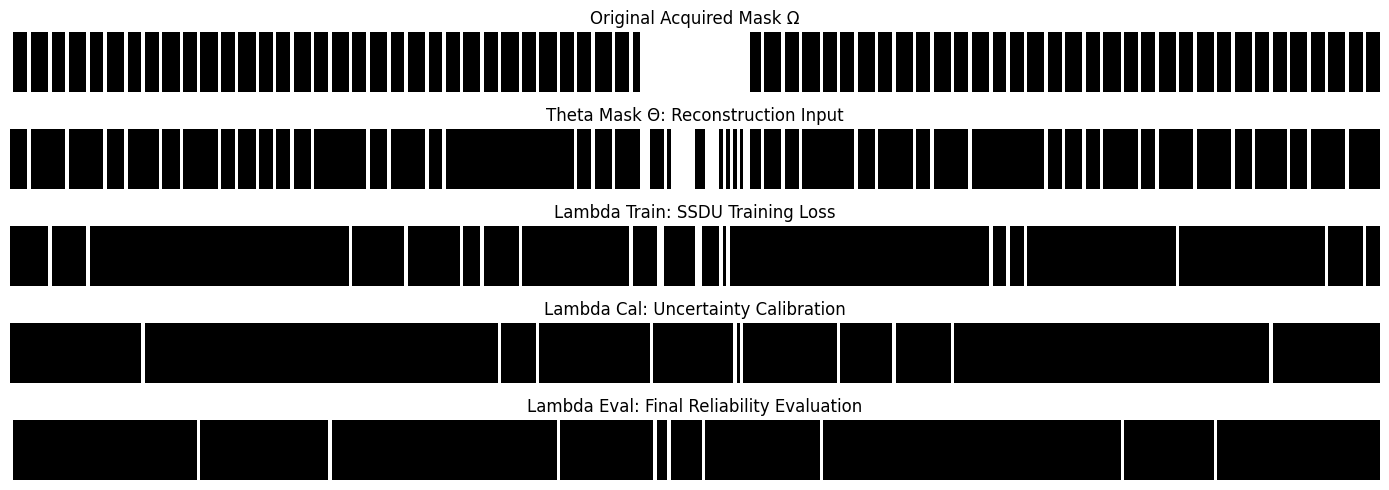

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(5, 1, 1)
plt.imshow(mask[None, :], cmap="gray", aspect="auto")
plt.title("Original Acquired Mask Ω")
plt.axis("off")

plt.subplot(5, 1, 2)
plt.imshow(theta_mask[None, :], cmap="gray", aspect="auto")
plt.title("Theta Mask Θ: Reconstruction Input")
plt.axis("off")

plt.subplot(5, 1, 3)
plt.imshow(lambda_train_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Train: SSDU Training Loss")
plt.axis("off")

plt.subplot(5, 1, 4)
plt.imshow(lambda_cal_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Cal: Uncertainty Calibration")
plt.axis("off")

plt.subplot(5, 1, 5)
plt.imshow(lambda_eval_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Eval: Final Reliability Evaluation")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Train on Lambda_train, evaluate on Lambda_cal and Lambda_eval**

In [ ]:
def run_four_way_reliability_experiment(
    kspace,
    mask,
    slice_index,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
):
    """
    Four-way SSDU reliability experiment.

    Train only on Lambda_train.
    Compute uncertainty-residual alignment separately on Lambda_cal and Lambda_eval.
    """

    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    # Select single-coil slice
    kspace_slice = kspace[slice_index]
    kspace_single = kspace_slice[coil_index]

    # Four-way SSDU split
    theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
        mask=mask,
        train_fraction=train_fraction,
        cal_fraction=cal_fraction,
        eval_fraction=eval_fraction,
        seed=split_seed,
    )

    # Prepare input from Theta only
    x_input, kspace_theta = prepare_single_coil_ssdu_input(
        kspace_single=kspace_single,
        theta_mask=theta_mask,
        normalize=True,
    )

    # Dropout model
    model = DropoutCNNReconstructor(
        in_channels=1,
        out_channels=1,
        features=features,
        dropout_p=dropout_p,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ssdu_history = []
    img_history = []

    model.train()

    for step in range(num_steps):
        optimizer.zero_grad()

        x_pred = model(x_input)

        # Train ONLY on Lambda_train
        total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
            x_pred_tensor=x_pred,
            x_input_tensor=x_input,
            kspace_single=kspace_single,
            lambda_mask=lambda_train_mask,
            lambda_img=lambda_img,
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        ssdu_history.append(ssdu_loss.item())
        img_history.append(img_loss.item())

    # Stochastic inference
    stochastic_outputs = stochastic_reconstructions(
        model=model,
        x_input_tensor=x_input,
        num_samples=num_samples,
    )

    mean_image, uncertainty_map = compute_mean_and_uncertainty(stochastic_outputs)

    # Calibration residual energy: Lambda_cal
    residual_energy_cal = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_cal_mask,
    )

    # Evaluation residual energy: Lambda_eval
    residual_energy_eval = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_eval_mask,
    )

    alignment_cal = map_alignment(
        uncertainty_map,
        residual_energy_cal,
    )

    alignment_eval = map_alignment(
        uncertainty_map,
        residual_energy_eval,
    )

    result = {
        "slice_index": slice_index,
        "coil_index": coil_index,
        "split_seed": split_seed,
        "model_seed": model_seed,
        "initial_train_ssdu_loss": ssdu_history[0],
        "final_train_ssdu_loss": ssdu_history[-1],
        "train_ssdu_reduction_percent": 100 * (ssdu_history[0] - ssdu_history[-1]) / ssdu_history[0],
        "initial_image_loss": img_history[0],
        "final_image_loss": img_history[-1],
        "alignment_cal": alignment_cal,
        "alignment_eval": alignment_eval,
        "loss_history": loss_history,
        "ssdu_history": ssdu_history,
        "img_history": img_history,
        "mean_image": mean_image,
        "uncertainty_map": uncertainty_map,
        "residual_energy_cal": residual_energy_cal,
        "residual_energy_eval": residual_energy_eval,
        "x_input": x_input.detach().cpu().numpy()[0, 0],
    }

    return result

**test it on slice 8 first:**

In [ ]:
four_way_result_8 = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
)

print("Slice:", four_way_result_8["slice_index"])
print("Initial train SSDU loss:", four_way_result_8["initial_train_ssdu_loss"])
print("Final train SSDU loss:", four_way_result_8["final_train_ssdu_loss"])
print("Training SSDU reduction %:", four_way_result_8["train_ssdu_reduction_percent"])
print("Calibration alignment:", four_way_result_8["alignment_cal"])
print("Evaluation alignment:", four_way_result_8["alignment_eval"])

Slice: 8
Initial train SSDU loss: 34236328.0
Final train SSDU loss: 20935760.0
Training SSDU reduction %: 38.849283135738155
Calibration alignment: 0.4237924124864184
Evaluation alignment: 0.5121614380155773


**Run four-way split across multiple slices**

In [ ]:
four_way_multi_slice_results = []

for slice_index in [4, 8, 12]:
    print(f"\nRunning four-way experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    four_way_multi_slice_results.append({
        "slice_index": slice_index,
        "initial_train_ssdu_loss": result["initial_train_ssdu_loss"],
        "final_train_ssdu_loss": result["final_train_ssdu_loss"],
        "train_ssdu_reduction_percent": result["train_ssdu_reduction_percent"],
        "alignment_cal": result["alignment_cal"],
        "alignment_eval": result["alignment_eval"],
    })

four_way_multi_slice_df = pd.DataFrame(four_way_multi_slice_results)
four_way_multi_slice_df


Running four-way experiment on slice 4...

Running four-way experiment on slice 8...

Running four-way experiment on slice 12...


,slice_index,initial_train_ssdu_loss,final_train_ssdu_loss,train_ssdu_reduction_percent,alignment_cal,alignment_eval
0,4,77422928.0,40357816.0,47.873560,0.392745,0.404839
1,8,34236328.0,20935760.0,38.849283,0.423792,0.512161
2,12,55932464.0,35439100.0,36.639480,0.432562,0.518162


In [ ]:
print(four_way_multi_slice_df)

print("\nMean training SSDU reduction %:", four_way_multi_slice_df["train_ssdu_reduction_percent"].mean())
print("Std training SSDU reduction %:", four_way_multi_slice_df["train_ssdu_reduction_percent"].std())

print("\nMean calibration alignment:", four_way_multi_slice_df["alignment_cal"].mean())
print("Std calibration alignment:", four_way_multi_slice_df["alignment_cal"].std())

print("\nMean evaluation alignment:", four_way_multi_slice_df["alignment_eval"].mean())
print("Std evaluation alignment:", four_way_multi_slice_df["alignment_eval"].std())
print("Min evaluation alignment:", four_way_multi_slice_df["alignment_eval"].min())
print("Max evaluation alignment:", four_way_multi_slice_df["alignment_eval"].max())

   slice_index  initial_train_ssdu_loss  final_train_ssdu_loss  \
0            4               77422928.0             40357816.0   
1            8               34236328.0             20935760.0   
2           12               55932464.0             35439100.0   

   train_ssdu_reduction_percent  alignment_cal  alignment_eval  
0                     47.873560       0.392745        0.404839  
1                     38.849283       0.423792        0.512161  
2                     36.639480       0.432562        0.518162  

Mean training SSDU reduction %: 41.120774449377706
Std training SSDU reduction %: 5.951545459625913

Mean calibration alignment: 0.4163666003789969
Std calibration alignment: 0.020921128027440235

Mean evaluation alignment: 0.47838748294110234
Std evaluation alignment: 0.0637655234827069
Min evaluation alignment: 0.40483894917749425
Max evaluation alignment: 0.5181620616302354


#**Test src/four_way_reliability.py**

In [ ]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [ ]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import four_way_reliability
importlib.reload(four_way_reliability)

from four_way_reliability import run_four_way_reliability_experiment

print("four_way_reliability.py imported successfully.")

four_way_reliability.py imported successfully.


**test it on slice 8:**

In [ ]:
test_four_way_result = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

print("Slice:", test_four_way_result["slice_index"])
print("Initial train SSDU loss:", test_four_way_result["initial_train_ssdu_loss"])
print("Final train SSDU loss:", test_four_way_result["final_train_ssdu_loss"])
print("Training SSDU reduction %:", test_four_way_result["train_ssdu_reduction_percent"])
print("Calibration alignment:", test_four_way_result["alignment_cal"])
print("Evaluation alignment:", test_four_way_result["alignment_eval"])

Slice: 8
Initial train SSDU loss: 34236328.0
Final train SSDU loss: 20935760.0
Training SSDU reduction %: 38.849283135738155
Calibration alignment: 0.4237924124864184
Evaluation alignment: 0.5121614380155773


#**Run four-way reliability test on all 16 slices**

In [ ]:
all_slice_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning four-way experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    all_slice_results.append({
        "slice_index": slice_index,
        "initial_train_ssdu_loss": result["initial_train_ssdu_loss"],
        "final_train_ssdu_loss": result["final_train_ssdu_loss"],
        "train_ssdu_reduction_percent": result["train_ssdu_reduction_percent"],
        "alignment_cal": result["alignment_cal"],
        "alignment_eval": result["alignment_eval"],
    })

all_slice_df = pd.DataFrame(all_slice_results)
all_slice_df


Running four-way experiment on slice 0...

Running four-way experiment on slice 1...

Running four-way experiment on slice 2...

Running four-way experiment on slice 3...

Running four-way experiment on slice 4...

Running four-way experiment on slice 5...

Running four-way experiment on slice 6...

Running four-way experiment on slice 7...

Running four-way experiment on slice 8...

Running four-way experiment on slice 9...

Running four-way experiment on slice 10...

Running four-way experiment on slice 11...

Running four-way experiment on slice 12...

Running four-way experiment on slice 13...

Running four-way experiment on slice 14...

Running four-way experiment on slice 15...


,slice_index,initial_train_ssdu_loss,final_train_ssdu_loss,train_ssdu_reduction_percent,alignment_cal,alignment_eval
0,0,195396224.0,88244456.0,54.838198,0.334921,0.381174
1,1,252891232.0,124315200.0,50.842424,0.355052,0.413082
2,2,134028280.0,67938592.0,49.310256,0.375022,0.438849
3,3,86146960.0,44620792.0,48.203869,0.343067,0.453341
4,4,77422928.0,40357816.0,47.873560,0.392745,0.404839
5,5,70205904.0,37586504.0,46.462474,0.347724,0.458414
6,6,36439496.0,21719716.0,40.395125,0.391536,0.446923
7,7,41045204.0,24071168.0,41.354493,0.371006,0.466606
8,8,34236328.0,20935760.0,38.849283,0.423792,0.512161
9,9,39558752.0,24140452.0,38.975699,0.428911,0.502314


In [ ]:
print(all_slice_df)

print("\nMean training SSDU reduction %:", all_slice_df["train_ssdu_reduction_percent"].mean())
print("Std training SSDU reduction %:", all_slice_df["train_ssdu_reduction_percent"].std())

print("\nMean calibration alignment:", all_slice_df["alignment_cal"].mean())
print("Std calibration alignment:", all_slice_df["alignment_cal"].std())
print("Min calibration alignment:", all_slice_df["alignment_cal"].min())
print("Max calibration alignment:", all_slice_df["alignment_cal"].max())

print("\nMean evaluation alignment:", all_slice_df["alignment_eval"].mean())
print("Std evaluation alignment:", all_slice_df["alignment_eval"].std())
print("Min evaluation alignment:", all_slice_df["alignment_eval"].min())
print("Max evaluation alignment:", all_slice_df["alignment_eval"].max())

    slice_index  initial_train_ssdu_loss  final_train_ssdu_loss  \
0             0              195396224.0             88244456.0   
1             1              252891232.0            124315200.0   
2             2              134028280.0             67938592.0   
3             3               86146960.0             44620792.0   
4             4               77422928.0             40357816.0   
5             5               70205904.0             37586504.0   
6             6               36439496.0             21719716.0   
7             7               41045204.0             24071168.0   
8             8               34236328.0             20935760.0   
9             9               39558752.0             24140452.0   
10           10               38363132.0             23740318.0   
11           11               50481560.0             31555356.0   
12           12               55932464.0             35439100.0   
13           13               73542912.0             48026876.

#**Baseline-controlled four-way reliability evaluation**

In [ ]:
def gradient_magnitude(image):
    """
    Compute simple gradient magnitude from a 2D image.
    """
    gy, gx = np.gradient(image)
    return np.sqrt(gx**2 + gy**2)


baseline_results = []

rng = np.random.default_rng(42)

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning baseline-controlled experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    residual_eval = result["residual_energy_eval"]
    uncertainty_map = result["uncertainty_map"]
    mean_image = result["mean_image"]
    x_input = result["x_input"]

    random_map = rng.random(residual_eval.shape)
    intensity_map = np.abs(mean_image)
    input_intensity_map = np.abs(x_input)
    edge_map = gradient_magnitude(mean_image)

    baseline_results.append({
        "slice_index": slice_index,
        "random_alignment": map_alignment(random_map, residual_eval),
        "input_intensity_alignment": map_alignment(input_intensity_map, residual_eval),
        "mean_intensity_alignment": map_alignment(intensity_map, residual_eval),
        "edge_alignment": map_alignment(edge_map, residual_eval),
        "dropout_uncertainty_alignment": map_alignment(uncertainty_map, residual_eval),
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df


Running baseline-controlled experiment on slice 0...

Running baseline-controlled experiment on slice 1...

Running baseline-controlled experiment on slice 2...

Running baseline-controlled experiment on slice 3...

Running baseline-controlled experiment on slice 4...

Running baseline-controlled experiment on slice 5...

Running baseline-controlled experiment on slice 6...

Running baseline-controlled experiment on slice 7...

Running baseline-controlled experiment on slice 8...

Running baseline-controlled experiment on slice 9...

Running baseline-controlled experiment on slice 10...

Running baseline-controlled experiment on slice 11...

Running baseline-controlled experiment on slice 12...

Running baseline-controlled experiment on slice 13...

Running baseline-controlled experiment on slice 14...

Running baseline-controlled experiment on slice 15...


,slice_index,random_alignment,input_intensity_alignment,mean_intensity_alignment,edge_alignment,dropout_uncertainty_alignment
0,0,-0.001131,0.478424,0.415558,0.303639,0.381174
1,1,-0.001883,0.491943,0.433852,0.319824,0.413082
2,2,0.000843,0.536322,0.431318,0.368996,0.438849
3,3,-0.000795,0.554698,0.450208,0.370511,0.453341
4,4,0.004495,0.495757,0.414697,0.334013,0.404839
5,5,0.000631,0.553531,0.448762,0.396892,0.458414
6,6,-0.001171,0.537193,0.462351,0.402467,0.446923
7,7,0.000133,0.546951,0.454261,0.401722,0.466606
8,8,-0.001885,0.588534,0.489111,0.453678,0.512161
9,9,-0.000154,0.579916,0.482784,0.417486,0.502314


In [ ]:
print(baseline_df)

summary = baseline_df.drop(columns=["slice_index"]).agg(["mean", "std", "min", "max"]).T
summary

    slice_index  random_alignment  input_intensity_alignment  \
0             0         -0.001131                   0.478424   
1             1         -0.001883                   0.491943   
2             2          0.000843                   0.536322   
3             3         -0.000795                   0.554698   
4             4          0.004495                   0.495757   
5             5          0.000631                   0.553531   
6             6         -0.001171                   0.537193   
7             7          0.000133                   0.546951   
8             8         -0.001885                   0.588534   
9             9         -0.000154                   0.579916   
10           10         -0.000073                   0.557620   
11           11          0.003698                   0.539779   
12           12         -0.000096                   0.585153   
13           13         -0.000106                   0.568752   
14           14          0.001043       

,mean,std,min,max
random_alignment,0.000277,0.001753,-0.001885,0.004495
input_intensity_alignment,0.552900,0.040571,0.478424,0.625273
mean_intensity_alignment,0.459942,0.036685,0.414697,0.547403
edge_alignment,0.394552,0.045329,0.303639,0.467798
dropout_uncertainty_alignment,0.470354,0.045251,0.381174,0.535252


**Compute baseline margins**

In [ ]:
baseline_margin_df = baseline_df.copy()

baseline_margin_df["dropout_minus_random"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["random_alignment"]
)

baseline_margin_df["dropout_minus_input_intensity"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["input_intensity_alignment"]
)

baseline_margin_df["dropout_minus_mean_intensity"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["mean_intensity_alignment"]
)

baseline_margin_df["dropout_minus_edge"] = (
    baseline_margin_df["dropout_uncertainty_alignment"]
    - baseline_margin_df["edge_alignment"]
)

baseline_margin_df[
    [
        "slice_index",
        "dropout_minus_random",
        "dropout_minus_input_intensity",
        "dropout_minus_mean_intensity",
        "dropout_minus_edge",
    ]
]

,slice_index,dropout_minus_random,dropout_minus_input_intensity,dropout_minus_mean_intensity,dropout_minus_edge
0,0,0.382305,-0.097250,-0.034384,0.077535
1,1,0.414965,-0.078861,-0.020770,0.093258
2,2,0.438007,-0.097473,0.007531,0.069853
3,3,0.454136,-0.101358,0.003133,0.082830
4,4,0.400344,-0.090918,-0.009858,0.070826
5,5,0.457783,-0.095117,0.009652,0.061522
6,6,0.448094,-0.090271,-0.015428,0.044455
7,7,0.466473,-0.080345,0.012346,0.064884
8,8,0.514047,-0.076373,0.023050,0.058483
9,9,0.502468,-0.077602,0.019530,0.084828


In [ ]:
margin_summary = baseline_margin_df[
    [
        "dropout_minus_random",
        "dropout_minus_input_intensity",
        "dropout_minus_mean_intensity",
        "dropout_minus_edge",
    ]
].agg(["mean", "std", "min", "max"]).T

margin_summary

,mean,std,min,max
dropout_minus_random,0.470077,0.045315,0.382305,0.534209
dropout_minus_input_intensity,-0.082546,0.014843,-0.107263,-0.057987
dropout_minus_mean_intensity,0.010412,0.027569,-0.034384,0.055404
dropout_minus_edge,0.075802,0.020927,0.044455,0.113939


#**Partial correlation analysis**

In [ ]:
def partial_correlation_with_controls(target_map, predictor_map, control_maps):
    """
    Compute partial correlation between predictor_map and target_map
    after removing linear effects of control_maps.

    target_map: residual energy map
    predictor_map: uncertainty map
    control_maps: list of maps, e.g. [input_intensity, edge_map]
    """
    y = normalize_map(target_map).ravel()
    x = normalize_map(predictor_map).ravel()

    controls = [normalize_map(c).ravel() for c in control_maps]
    C = np.stack(controls, axis=1)

    # Add intercept
    C = np.concatenate([np.ones((C.shape[0], 1)), C], axis=1)

    # Residualize y against controls
    beta_y, *_ = np.linalg.lstsq(C, y, rcond=None)
    y_res = y - C @ beta_y

    # Residualize x against controls
    beta_x, *_ = np.linalg.lstsq(C, x, rcond=None)
    x_res = x - C @ beta_x

    if np.std(y_res) == 0 or np.std(x_res) == 0:
        return 0.0

    return np.corrcoef(x_res, y_res)[0, 1]

**rerun the all-slice experiment with partial correlation:**

In [ ]:
partial_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning partial-correlation experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    residual_eval = result["residual_energy_eval"]
    uncertainty_map = result["uncertainty_map"]
    mean_image = result["mean_image"]
    x_input = result["x_input"]

    input_intensity = np.abs(x_input)
    mean_intensity = np.abs(mean_image)
    edge_map = gradient_magnitude(mean_image)

    raw_dropout_alignment = map_alignment(
        uncertainty_map,
        residual_eval
    )

    partial_input_edge = partial_correlation_with_controls(
        target_map=residual_eval,
        predictor_map=uncertainty_map,
        control_maps=[input_intensity, edge_map]
    )

    partial_input_mean_edge = partial_correlation_with_controls(
        target_map=residual_eval,
        predictor_map=uncertainty_map,
        control_maps=[input_intensity, mean_intensity, edge_map]
    )

    partial_results.append({
        "slice_index": slice_index,
        "raw_dropout_alignment": raw_dropout_alignment,
        "partial_control_input_edge": partial_input_edge,
        "partial_control_input_mean_edge": partial_input_mean_edge,
    })

partial_df = pd.DataFrame(partial_results)
partial_df


Running partial-correlation experiment on slice 0...

Running partial-correlation experiment on slice 1...

Running partial-correlation experiment on slice 2...

Running partial-correlation experiment on slice 3...

Running partial-correlation experiment on slice 4...

Running partial-correlation experiment on slice 5...

Running partial-correlation experiment on slice 6...

Running partial-correlation experiment on slice 7...

Running partial-correlation experiment on slice 8...

Running partial-correlation experiment on slice 9...

Running partial-correlation experiment on slice 10...

Running partial-correlation experiment on slice 11...

Running partial-correlation experiment on slice 12...

Running partial-correlation experiment on slice 13...

Running partial-correlation experiment on slice 14...

Running partial-correlation experiment on slice 15...


,slice_index,raw_dropout_alignment,partial_control_input_edge,partial_control_input_mean_edge
0,0,0.381174,0.073196,0.071740
1,1,0.413082,0.074840,0.072704
2,2,0.438849,0.063527,0.057802
3,3,0.453341,0.060433,0.053263
4,4,0.404839,0.049602,0.044119
5,5,0.458414,0.062420,0.053354
6,6,0.446923,0.036544,0.032893
7,7,0.466606,0.055222,0.044953
8,8,0.512161,0.059634,0.046297
9,9,0.502314,0.053606,0.038432


In [ ]:
print(partial_df)

partial_summary = partial_df.drop(columns=["slice_index"]).agg(
    ["mean", "std", "min", "max"]
).T

partial_summary

    slice_index  raw_dropout_alignment  partial_control_input_edge  \
0             0               0.381174                    0.073196   
1             1               0.413082                    0.074840   
2             2               0.438849                    0.063527   
3             3               0.453341                    0.060433   
4             4               0.404839                    0.049602   
5             5               0.458414                    0.062420   
6             6               0.446923                    0.036544   
7             7               0.466606                    0.055222   
8             8               0.512161                    0.059634   
9             9               0.502314                    0.053606   
10           10               0.491335                    0.062980   
11           11               0.481792                    0.058469   
12           12               0.518162                    0.045843   
13           13     

,mean,std,min,max
raw_dropout_alignment,0.470354,0.045251,0.381174,0.535252
partial_control_input_edge,0.056158,0.013597,0.029635,0.075170
partial_control_input_mean_edge,0.047367,0.017518,0.015509,0.081817


#**Define calibration utilities**

In [ ]:
def flatten_norm(x, eps=1e-12):
    """
    Normalize a 2D map to [0, 1] and flatten it.
    """
    x = np.asarray(x)
    x = np.abs(x)
    return ((x - x.min()) / (x.max() - x.min() + eps)).ravel()


def fit_ridge_reliability_map(
    target_map,
    predictor_maps,
    output_shape,
    ridge_lambda=1e-3,
):
    """
    Fit a simple ridge regression reliability map.

    target_map:
        Calibration residual energy map.

    predictor_maps:
        List of predictor maps, for example:
        [dropout_uncertainty, input_intensity, edge_map]

    output_shape:
        Shape of the output 2D reliability map.

    ridge_lambda:
        Small ridge penalty for numerical stability.
    """
    y = flatten_norm(target_map)

    X_list = [flatten_norm(p) for p in predictor_maps]
    X = np.stack(X_list, axis=1)

    # Add intercept
    X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)

    # Ridge regression: beta = (X^T X + lambda I)^-1 X^T y
    I = np.eye(X.shape[1])
    I[0, 0] = 0.0  # do not penalize intercept

    beta = np.linalg.solve(
        X.T @ X + ridge_lambda * I,
        X.T @ y
    )

    pred = X @ beta
    reliability_map = pred.reshape(output_shape)

    return reliability_map, beta

**Test calibrated reliability on one slice first**

In [ ]:
cal_test_result = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

residual_cal = cal_test_result["residual_energy_cal"]
residual_eval = cal_test_result["residual_energy_eval"]

U = cal_test_result["uncertainty_map"]
x_input = cal_test_result["x_input"]
mean_image = cal_test_result["mean_image"]

I_input = np.abs(x_input)
I_mean = np.abs(mean_image)
G = gradient_magnitude(mean_image)

# Structural calibrated baseline: intensity + edge only
R_struct, beta_struct = fit_ridge_reliability_map(
    target_map=residual_cal,
    predictor_maps=[I_input, G],
    output_shape=residual_cal.shape,
    ridge_lambda=1e-3,
)

# Hybrid calibrated reliability: dropout uncertainty + intensity + edge
R_hybrid, beta_hybrid = fit_ridge_reliability_map(
    target_map=residual_cal,
    predictor_maps=[U, I_input, G],
    output_shape=residual_cal.shape,
    ridge_lambda=1e-3,
)

# Compare on Lambda_eval only
raw_dropout_eval = map_alignment(U, residual_eval)
input_intensity_eval = map_alignment(I_input, residual_eval)
edge_eval = map_alignment(G, residual_eval)
struct_eval = map_alignment(R_struct, residual_eval)
hybrid_eval = map_alignment(R_hybrid, residual_eval)

print("Raw dropout eval alignment:", raw_dropout_eval)
print("Input intensity eval alignment:", input_intensity_eval)
print("Edge eval alignment:", edge_eval)
print("Calibrated structural eval alignment:", struct_eval)
print("Calibrated hybrid eval alignment:", hybrid_eval)

print("\nBeta structural:", beta_struct)
print("Beta hybrid:", beta_hybrid)

Raw dropout eval alignment: 0.5121614380155773
Input intensity eval alignment: 0.58853405850503
Edge eval alignment: 0.45367810157140487
Calibrated structural eval alignment: 0.593640236481623
Calibrated hybrid eval alignment: 0.594585207696328

Beta structural: [-0.00387491  0.30595364  0.04965098]
Beta hybrid: [-0.01076191  0.02358463  0.29513807  0.04922764]


**residual-calibrated reliability across all slices**

In [ ]:
calibrated_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning calibrated reliability experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    residual_cal = result["residual_energy_cal"]
    residual_eval = result["residual_energy_eval"]

    U = result["uncertainty_map"]
    x_input = result["x_input"]
    mean_image = result["mean_image"]

    I_input = np.abs(x_input)
    I_mean = np.abs(mean_image)
    G = gradient_magnitude(mean_image)

    # Structural calibrated baseline: input intensity + edge
    R_struct, beta_struct = fit_ridge_reliability_map(
        target_map=residual_cal,
        predictor_maps=[I_input, G],
        output_shape=residual_cal.shape,
        ridge_lambda=1e-3,
    )

    # Hybrid calibrated reliability: dropout uncertainty + input intensity + edge
    R_hybrid, beta_hybrid = fit_ridge_reliability_map(
        target_map=residual_cal,
        predictor_maps=[U, I_input, G],
        output_shape=residual_cal.shape,
        ridge_lambda=1e-3,
    )

    raw_dropout_eval = map_alignment(U, residual_eval)
    input_intensity_eval = map_alignment(I_input, residual_eval)
    mean_intensity_eval = map_alignment(I_mean, residual_eval)
    edge_eval = map_alignment(G, residual_eval)
    struct_eval = map_alignment(R_struct, residual_eval)
    hybrid_eval = map_alignment(R_hybrid, residual_eval)

    calibrated_results.append({
        "slice_index": slice_index,
        "raw_dropout_eval": raw_dropout_eval,
        "input_intensity_eval": input_intensity_eval,
        "mean_intensity_eval": mean_intensity_eval,
        "edge_eval": edge_eval,
        "struct_calibrated_eval": struct_eval,
        "hybrid_calibrated_eval": hybrid_eval,
        "hybrid_minus_dropout": hybrid_eval - raw_dropout_eval,
        "hybrid_minus_input": hybrid_eval - input_intensity_eval,
        "hybrid_minus_struct": hybrid_eval - struct_eval,
        "beta_U": beta_hybrid[1],
        "beta_input": beta_hybrid[2],
        "beta_edge": beta_hybrid[3],
    })

calibrated_df = pd.DataFrame(calibrated_results)
calibrated_df


Running calibrated reliability experiment on slice 0...

Running calibrated reliability experiment on slice 1...

Running calibrated reliability experiment on slice 2...

Running calibrated reliability experiment on slice 3...

Running calibrated reliability experiment on slice 4...

Running calibrated reliability experiment on slice 5...

Running calibrated reliability experiment on slice 6...

Running calibrated reliability experiment on slice 7...

Running calibrated reliability experiment on slice 8...

Running calibrated reliability experiment on slice 9...

Running calibrated reliability experiment on slice 10...

Running calibrated reliability experiment on slice 11...

Running calibrated reliability experiment on slice 12...

Running calibrated reliability experiment on slice 13...

Running calibrated reliability experiment on slice 14...

Running calibrated reliability experiment on slice 15...


,slice_index,raw_dropout_eval,input_intensity_eval,mean_intensity_eval,edge_eval,struct_calibrated_eval,hybrid_calibrated_eval,hybrid_minus_dropout,hybrid_minus_input,hybrid_minus_struct,beta_U,beta_input,beta_edge
0,0,0.381174,0.478424,0.415558,0.303639,0.482400,0.485981,0.104807,0.007557,0.003581,0.049486,0.235665,0.060107
1,1,0.413082,0.491943,0.433852,0.319824,0.494262,0.498170,0.085087,0.006227,0.003908,0.091797,0.228951,0.146319
2,2,0.438849,0.536322,0.431318,0.368996,0.541539,0.544126,0.105277,0.007804,0.002587,0.061812,0.209644,0.056991
3,3,0.453341,0.554698,0.450208,0.370511,0.559615,0.560852,0.107511,0.006153,0.001237,0.031779,0.343018,0.127870
4,4,0.404839,0.495757,0.414697,0.334013,0.498383,0.500235,0.095396,0.004478,0.001852,0.056033,0.274048,0.038849
5,5,0.458414,0.553531,0.448762,0.396892,0.555065,0.556637,0.098223,0.003106,0.001572,0.034496,0.281592,0.011520
6,6,0.446923,0.537193,0.462351,0.402467,0.540616,0.541473,0.094551,0.004280,0.000857,0.037518,0.276598,0.036648
7,7,0.466606,0.546951,0.454261,0.401722,0.548564,0.549625,0.083019,0.002673,0.001061,0.032979,0.340219,0.020809
8,8,0.512161,0.588534,0.489111,0.453678,0.593640,0.594585,0.082424,0.006051,0.000945,0.023585,0.295138,0.049228
9,9,0.502314,0.579916,0.482784,0.417486,0.583694,0.584205,0.081891,0.004289,0.000511,0.016511,0.386742,0.078288


In [ ]:
print(calibrated_df)

calibrated_summary = calibrated_df.drop(columns=["slice_index"]).agg(
    ["mean", "std", "min", "max"]
).T

calibrated_summary

    slice_index  raw_dropout_eval  input_intensity_eval  mean_intensity_eval  \
0             0          0.381174              0.478424             0.415558   
1             1          0.413082              0.491943             0.433852   
2             2          0.438849              0.536322             0.431318   
3             3          0.453341              0.554698             0.450208   
4             4          0.404839              0.495757             0.414697   
5             5          0.458414              0.553531             0.448762   
6             6          0.446923              0.537193             0.462351   
7             7          0.466606              0.546951             0.454261   
8             8          0.512161              0.588534             0.489111   
9             9          0.502314              0.579916             0.482784   
10           10          0.491335              0.557620             0.435931   
11           11          0.481792       

,mean,std,min,max
raw_dropout_eval,0.470354,0.045251,0.381174,0.535252
input_intensity_eval,0.552900,0.040571,0.478424,0.625273
mean_intensity_eval,0.459942,0.036685,0.414697,0.547403
edge_eval,0.394552,0.045329,0.303639,0.467798
struct_calibrated_eval,0.557906,0.042037,0.482400,0.636130
hybrid_calibrated_eval,0.559571,0.041464,0.485981,0.638742
hybrid_minus_dropout,0.089217,0.015198,0.065077,0.120732
hybrid_minus_input,0.006671,0.004148,-0.000260,0.014063
hybrid_minus_struct,0.001665,0.001058,0.000413,0.003908
beta_U,0.050111,0.021424,0.016511,0.091797


#**Test src/calibration.py**

In [ ]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [ ]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import calibration
importlib.reload(calibration)

from calibration import (
    gradient_magnitude,
    fit_structural_reliability_map,
    fit_hybrid_reliability_map,
)

print("calibration.py imported successfully.")

calibration.py imported successfully.


**test it on slice 8:**

In [ ]:
cal_util_result = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

residual_cal = cal_util_result["residual_energy_cal"]
residual_eval = cal_util_result["residual_energy_eval"]

U = cal_util_result["uncertainty_map"]
x_input = cal_util_result["x_input"]
mean_image = cal_util_result["mean_image"]

I_input = abs(x_input)
G = gradient_magnitude(mean_image)

R_struct, beta_struct = fit_structural_reliability_map(
    residual_cal=residual_cal,
    input_image=x_input,
    mean_image=mean_image,
    ridge_lambda=1e-3,
)

R_hybrid, beta_hybrid = fit_hybrid_reliability_map(
    residual_cal=residual_cal,
    uncertainty_map=U,
    input_image=x_input,
    mean_image=mean_image,
    ridge_lambda=1e-3,
)

raw_dropout_eval = map_alignment(U, residual_eval)
input_intensity_eval = map_alignment(I_input, residual_eval)
edge_eval = map_alignment(G, residual_eval)
struct_eval = map_alignment(R_struct, residual_eval)
hybrid_eval = map_alignment(R_hybrid, residual_eval)

print("Raw dropout eval alignment:", raw_dropout_eval)
print("Input intensity eval alignment:", input_intensity_eval)
print("Edge eval alignment:", edge_eval)
print("Structural calibrated eval alignment:", struct_eval)
print("Hybrid calibrated eval alignment:", hybrid_eval)

print("\nBeta structural:", beta_struct)
print("Beta hybrid:", beta_hybrid)

Raw dropout eval alignment: 0.5121614380155773
Input intensity eval alignment: 0.58853405850503
Edge eval alignment: 0.45367810157140487
Structural calibrated eval alignment: 0.593640236481623
Hybrid calibrated eval alignment: 0.594585207696328

Beta structural: [-0.00387491  0.30595364  0.04965098]
Beta hybrid: [-0.01076191  0.02358463  0.29513807  0.04922764]


#**Test the heteroscedastic CNN model**

In [ ]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


**Import the model:**

In [ ]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from models.heteroscedastic_cnn import HeteroscedasticCNNReconstructor

print("HeteroscedasticCNNReconstructor imported successfully.")

HeteroscedasticCNNReconstructor imported successfully.


**prepare a test input from slice 8:**

In [ ]:
from ssdu import split_acquired_mask_four_way
from training import prepare_single_coil_ssdu_input

slice_index = 8
coil_index = 0

kspace_single = kspace[slice_index, coil_index]

theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
    mask=mask,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    seed=42
)

x_input_hetero, _ = prepare_single_coil_ssdu_input(
    kspace_single=kspace_single,
    theta_mask=theta_mask,
    normalize=True
)

print("Input shape:", x_input_hetero.shape)

Input shape: torch.Size([1, 1, 768, 396])


**run a forward pass:**

In [ ]:
hetero_model = HeteroscedasticCNNReconstructor(
    in_channels=1,
    features=16
)

hetero_model.train()

x_hat, sigma2_hat = hetero_model(x_input_hetero)

print("x_hat shape:", x_hat.shape)
print("sigma2_hat shape:", sigma2_hat.shape)

print("sigma2 min:", sigma2_hat.min().item())
print("sigma2 max:", sigma2_hat.max().item())
print("sigma2 mean:", sigma2_hat.mean().item())

x_hat shape: torch.Size([1, 1, 768, 396])
sigma2_hat shape: torch.Size([1, 1, 768, 396])
sigma2 min: 0.6488534212112427
sigma2 max: 0.6631097793579102
sigma2 mean: 0.6553208231925964


**Define heteroscedastic calibration loss**

In [ ]:
from training import torch_fft2c, image_consistency_loss, single_coil_ssdu_loss

def torch_ifft2c(kspace):
    """
    Centered inverse 2D FFT for PyTorch complex tensors.
    """
    image = torch.fft.fftshift(
        torch.fft.ifft2(
            torch.fft.ifftshift(kspace, dim=(-2, -1)),
            norm="ortho"
        ),
        dim=(-2, -1)
    )
    return image


def torch_normalize_map(x, eps=1e-12):
    """
    Normalize tensor map to [0, 1].
    """
    x = torch.abs(x)
    return (x - x.min()) / (x.max() - x.min() + eps)


def lambda_residual_energy_torch(x_hat_tensor, kspace_single, lambda_mask):
    """
    Compute differentiable image-domain residual energy from a Lambda mask.
    """
    x_hat = x_hat_tensor[0, 0]

    k_pred = torch_fft2c(x_hat)

    lambda_mask_2d = lambda_mask[None, :]

    true_lambda = lambda_mask_2d * kspace_single

    true_lambda_torch = torch.from_numpy(true_lambda).to(k_pred.device)
    lambda_mask_torch = torch.from_numpy(lambda_mask_2d).float().to(k_pred.device)

    residual_lambda = lambda_mask_torch * (k_pred - true_lambda_torch)

    residual_img = torch_ifft2c(residual_lambda)

    residual_energy = torch.abs(residual_img) ** 2

    return residual_energy


def heteroscedastic_calibration_loss(
    sigma2_hat,
    residual_energy_cal,
):
    """
    Train sigma2_hat to match normalized calibration residual energy.

    This is a first simple calibration loss.
    """
    sigma_map = sigma2_hat[0, 0]

    sigma_norm = torch_normalize_map(sigma_map)
    residual_norm = torch_normalize_map(residual_energy_cal.detach())

    loss = torch.mean((sigma_norm - residual_norm) ** 2)

    return loss

**Train heteroscedastic model on slice 8**

In [ ]:
hetero_model = HeteroscedasticCNNReconstructor(
    in_channels=1,
    features=16
)

optimizer = torch.optim.Adam(hetero_model.parameters(), lr=1e-4)

num_steps = 50
lambda_img = 1e7
lambda_cal = 1e6

hetero_loss_history = []
hetero_ssdu_history = []
hetero_img_history = []
hetero_cal_history = []

hetero_model.train()

for step in range(num_steps):
    optimizer.zero_grad()

    x_hat, sigma2_hat = hetero_model(x_input_hetero)

    # Reconstruction loss only on Lambda_train
    ssdu_loss = single_coil_ssdu_loss(
        x_pred_tensor=x_hat,
        kspace_single=kspace_single,
        lambda_mask=lambda_train_mask,
    )

    # Image consistency
    img_loss = image_consistency_loss(
        x_pred_tensor=x_hat,
        x_input_tensor=x_input_hetero,
    )

    # Calibration residual energy only from Lambda_cal
    residual_energy_cal_torch = lambda_residual_energy_torch(
        x_hat_tensor=x_hat,
        kspace_single=kspace_single,
        lambda_mask=lambda_cal_mask,
    )

    cal_loss = heteroscedastic_calibration_loss(
        sigma2_hat=sigma2_hat,
        residual_energy_cal=residual_energy_cal_torch,
    )

    total_loss = ssdu_loss + lambda_img * img_loss + lambda_cal * cal_loss

    total_loss.backward()
    optimizer.step()

    hetero_loss_history.append(total_loss.item())
    hetero_ssdu_history.append(ssdu_loss.item())
    hetero_img_history.append(img_loss.item())
    hetero_cal_history.append(cal_loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(
            f"Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f} | "
            f"Cal: {cal_loss.item():.6f}"
        )

Step 000 | Total: 25489322.000000 | SSDU: 24739062.000000 | Image: 0.065438 | Cal: 0.095880
Step 010 | Total: 21958880.000000 | SSDU: 21299066.000000 | Image: 0.057320 | Cal: 0.086619
Step 020 | Total: 20115910.000000 | SSDU: 19532778.000000 | Image: 0.049856 | Cal: 0.084571
Step 030 | Total: 18554968.000000 | SSDU: 17998914.000000 | Image: 0.048759 | Cal: 0.068465
Step 040 | Total: 16771768.000000 | SSDU: 16223922.000000 | Image: 0.049544 | Cal: 0.052409
Step 049 | Total: 14928573.000000 | SSDU: 14381544.000000 | Image: 0.050291 | Cal: 0.044117


Evaluate learned uncertainty head on Λ
eval
	​
**bold text**

In [ ]:
hetero_model.eval()

with torch.no_grad():
    x_hat_hetero, sigma2_hat_hetero = hetero_model(x_input_hetero)

x_hat_hetero_np = x_hat_hetero.detach().cpu().numpy()[0, 0]
sigma2_hetero_np = sigma2_hat_hetero.detach().cpu().numpy()[0, 0]

# Evaluation residual energy from Lambda_eval
residual_eval_hetero = backproject_lambda_residual(
    mean_image=x_hat_hetero_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_eval_mask
)

# Baseline maps
I_input = np.abs(x_input_hetero.detach().cpu().numpy()[0, 0])
I_hat = np.abs(x_hat_hetero_np)
G_hat = gradient_magnitude(x_hat_hetero_np)

# Alignments
sigma2_eval_alignment = map_alignment(
    sigma2_hetero_np,
    residual_eval_hetero
)

input_intensity_alignment = map_alignment(
    I_input,
    residual_eval_hetero
)

recon_intensity_alignment = map_alignment(
    I_hat,
    residual_eval_hetero
)

edge_alignment = map_alignment(
    G_hat,
    residual_eval_hetero
)

print("Learned sigma2 eval alignment:", sigma2_eval_alignment)
print("Input intensity eval alignment:", input_intensity_alignment)
print("Reconstruction intensity eval alignment:", recon_intensity_alignment)
print("Edge eval alignment:", edge_alignment)

print("\nSigma2 min:", sigma2_hetero_np.min())
print("Sigma2 max:", sigma2_hetero_np.max())
print("Sigma2 mean:", sigma2_hetero_np.mean())
print("Sigma2 std:", sigma2_hetero_np.std())

Learned sigma2 eval alignment: -0.2462227534602691
Input intensity eval alignment: 0.577943078130945
Reconstruction intensity eval alignment: 0.4574855111850025
Edge eval alignment: 0.4435558759307484

Sigma2 min: 0.70512736
Sigma2 max: 0.7314825
Sigma2 mean: 0.7106744
Sigma2 std: 0.0009846357


**visualize:**

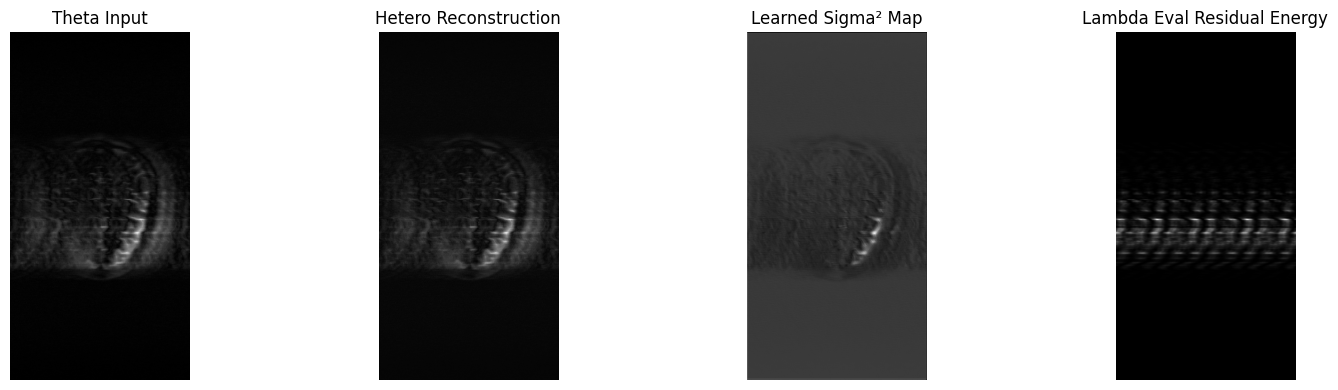

In [ ]:
sigma2_norm = normalize_map(sigma2_hetero_np)
residual_eval_norm = normalize_map(residual_eval_hetero)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(I_input, cmap="gray")
plt.title("Theta Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x_hat_hetero_np, cmap="gray")
plt.title("Hetero Reconstruction")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(sigma2_norm, cmap="gray")
plt.title("Learned Sigma² Map")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(residual_eval_norm, cmap="gray")
plt.title("Lambda Eval Residual Energy")
plt.axis("off")

plt.tight_layout()
plt.show()

**Check whether sigma² learned calibration residual but failed evaluation**

In [ ]:
# Compute calibration residual energy from the final hetero reconstruction
residual_cal_hetero = backproject_lambda_residual(
    mean_image=x_hat_hetero_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_cal_mask
)

sigma2_cal_alignment = map_alignment(
    sigma2_hetero_np,
    residual_cal_hetero
)

sigma2_eval_alignment = map_alignment(
    sigma2_hetero_np,
    residual_eval_hetero
)

input_cal_alignment = map_alignment(
    I_input,
    residual_cal_hetero
)

input_eval_alignment = map_alignment(
    I_input,
    residual_eval_hetero
)

edge_cal_alignment = map_alignment(
    G_hat,
    residual_cal_hetero
)

edge_eval_alignment = map_alignment(
    G_hat,
    residual_eval_hetero
)

print("Sigma² vs Lambda_cal residual:", sigma2_cal_alignment)
print("Sigma² vs Lambda_eval residual:", sigma2_eval_alignment)

print("\nInput intensity vs Lambda_cal residual:", input_cal_alignment)
print("Input intensity vs Lambda_eval residual:", input_eval_alignment)

print("\nEdge vs Lambda_cal residual:", edge_cal_alignment)
print("Edge vs Lambda_eval residual:", edge_eval_alignment)

Sigma² vs Lambda_cal residual: -0.1940507451744659
Sigma² vs Lambda_eval residual: -0.2462227534602691

Input intensity vs Lambda_cal residual: 0.4991804186949122
Input intensity vs Lambda_eval residual: 0.577943078130945

Edge vs Lambda_cal residual: 0.35012828669372836
Edge vs Lambda_eval residual: 0.4435558759307484


**Reinitialize model and train reconstruction only**

In [ ]:
hetero_stage_model = HeteroscedasticCNNReconstructor(
    in_channels=1,
    features=16
)

optimizer = torch.optim.Adam(hetero_stage_model.parameters(), lr=1e-4)

num_steps_stage1 = 50
lambda_img = 1e7

stage1_ssdu_history = []
stage1_img_history = []
stage1_total_history = []

hetero_stage_model.train()

for step in range(num_steps_stage1):
    optimizer.zero_grad()

    x_hat, sigma2_hat = hetero_stage_model(x_input_hetero)

    ssdu_loss = single_coil_ssdu_loss(
        x_pred_tensor=x_hat,
        kspace_single=kspace_single,
        lambda_mask=lambda_train_mask,
    )

    img_loss = image_consistency_loss(
        x_pred_tensor=x_hat,
        x_input_tensor=x_input_hetero,
    )

    total_loss = ssdu_loss + lambda_img * img_loss

    total_loss.backward()
    optimizer.step()

    stage1_total_history.append(total_loss.item())
    stage1_ssdu_history.append(ssdu_loss.item())
    stage1_img_history.append(img_loss.item())

    if step % 10 == 0 or step == num_steps_stage1 - 1:
        print(
            f"Stage 1 | Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f}"
        )

Stage 1 | Step 000 | Total: 39463624.000000 | SSDU: 39434656.000000 | Image: 0.002897
Stage 1 | Step 010 | Total: 31329110.000000 | SSDU: 31212394.000000 | Image: 0.011672
Stage 1 | Step 020 | Total: 26522518.000000 | SSDU: 26293608.000000 | Image: 0.022891
Stage 1 | Step 030 | Total: 24087448.000000 | SSDU: 23772944.000000 | Image: 0.031450
Stage 1 | Step 040 | Total: 22479582.000000 | SSDU: 22102076.000000 | Image: 0.037751
Stage 1 | Step 049 | Total: 20806870.000000 | SSDU: 20387186.000000 | Image: 0.041968


**Compute fixed calibration residual target**

In [ ]:
hetero_stage_model.eval()

with torch.no_grad():
    x_hat_stage1, sigma2_stage1 = hetero_stage_model(x_input_hetero)

# Fixed calibration residual target from Lambda_cal
residual_cal_fixed = lambda_residual_energy_torch(
    x_hat_tensor=x_hat_stage1,
    kspace_single=kspace_single,
    lambda_mask=lambda_cal_mask,
)

residual_cal_fixed_norm = torch_normalize_map(residual_cal_fixed).detach()

print("Fixed calibration residual shape:", residual_cal_fixed_norm.shape)
print("Fixed calibration residual min:", residual_cal_fixed_norm.min().item())
print("Fixed calibration residual max:", residual_cal_fixed_norm.max().item())

Fixed calibration residual shape: torch.Size([768, 396])
Fixed calibration residual min: 0.0
Fixed calibration residual max: 1.0


**Freeze reconstruction pathway and train only uncertainty head**

In [ ]:
# Freeze encoder and reconstruction head
for param in hetero_stage_model.encoder.parameters():
    param.requires_grad = False

for param in hetero_stage_model.reconstruction_head.parameters():
    param.requires_grad = False

# Train only log variance head
for param in hetero_stage_model.log_variance_head.parameters():
    param.requires_grad = True

optimizer_sigma = torch.optim.Adam(
    hetero_stage_model.log_variance_head.parameters(),
    lr=1e-3
)

num_steps_stage2 = 200

stage2_cal_history = []

hetero_stage_model.train()

for step in range(num_steps_stage2):
    optimizer_sigma.zero_grad()

    x_hat_fixed, sigma2_hat = hetero_stage_model(x_input_hetero)

    sigma_norm = torch_normalize_map(sigma2_hat[0, 0])

    cal_loss = torch.mean((sigma_norm - residual_cal_fixed_norm) ** 2)

    cal_loss.backward()
    optimizer_sigma.step()

    stage2_cal_history.append(cal_loss.item())

    if step % 25 == 0 or step == num_steps_stage2 - 1:
        print(
            f"Stage 2 | Step {step:03d} | "
            f"Cal loss: {cal_loss.item():.6f}"
        )

Stage 2 | Step 000 | Cal loss: 0.175652
Stage 2 | Step 025 | Cal loss: 0.007222
Stage 2 | Step 050 | Cal loss: 0.005334
Stage 2 | Step 075 | Cal loss: 0.004465
Stage 2 | Step 100 | Cal loss: 0.004025
Stage 2 | Step 125 | Cal loss: 0.003742
Stage 2 | Step 150 | Cal loss: 0.003606
Stage 2 | Step 175 | Cal loss: 0.003504
Stage 2 | Step 199 | Cal loss: 0.003426


**Evaluate two-stage learned sigma² on Lambda eval**

In [ ]:
hetero_stage_model.eval()

with torch.no_grad():
    x_hat_twostage, sigma2_twostage = hetero_stage_model(x_input_hetero)

x_hat_twostage_np = x_hat_twostage.detach().cpu().numpy()[0, 0]
sigma2_twostage_np = sigma2_twostage.detach().cpu().numpy()[0, 0]

residual_eval_twostage = backproject_lambda_residual(
    mean_image=x_hat_twostage_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_eval_mask
)

residual_cal_twostage = backproject_lambda_residual(
    mean_image=x_hat_twostage_np,
    measured_kspace=kspace_single,
    lambda_mask=lambda_cal_mask
)

I_input = np.abs(x_input_hetero.detach().cpu().numpy()[0, 0])
I_hat = np.abs(x_hat_twostage_np)
G_hat = gradient_magnitude(x_hat_twostage_np)

sigma2_cal_alignment = map_alignment(
    sigma2_twostage_np,
    residual_cal_twostage
)

sigma2_eval_alignment = map_alignment(
    sigma2_twostage_np,
    residual_eval_twostage
)

input_eval_alignment = map_alignment(
    I_input,
    residual_eval_twostage
)

recon_intensity_eval_alignment = map_alignment(
    I_hat,
    residual_eval_twostage
)

edge_eval_alignment = map_alignment(
    G_hat,
    residual_eval_twostage
)

print("Two-stage sigma² vs Lambda_cal residual:", sigma2_cal_alignment)
print("Two-stage sigma² vs Lambda_eval residual:", sigma2_eval_alignment)

print("\nInput intensity vs Lambda_eval residual:", input_eval_alignment)
print("Reconstruction intensity vs Lambda_eval residual:", recon_intensity_eval_alignment)
print("Edge vs Lambda_eval residual:", edge_eval_alignment)

print("\nSigma² min:", sigma2_twostage_np.min())
print("Sigma² max:", sigma2_twostage_np.max())
print("Sigma² mean:", sigma2_twostage_np.mean())
print("Sigma² std:", sigma2_twostage_np.std())

Two-stage sigma² vs Lambda_cal residual: 0.42092645851076643
Two-stage sigma² vs Lambda_eval residual: 0.44735994637431187

Input intensity vs Lambda_eval residual: 0.5875119652669648
Reconstruction intensity vs Lambda_eval residual: 0.5052222449939376
Edge vs Lambda_eval residual: 0.4570991669978361

Sigma² min: 0.66120404
Sigma² max: 0.7240481
Sigma² mean: 0.6634507
Sigma² std: 0.0032941569


#**Test ReliabilityCNN**

In [ ]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [ ]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import models.reliability_cnn
importlib.reload(models.reliability_cnn)

from models.reliability_cnn import ReliabilityCNN

print("ReliabilityCNN imported successfully.")

ReliabilityCNN imported successfully.


In [ ]:
test_reliability_model = ReliabilityCNN(
    in_channels=3,
    features=16
)

dummy_input = torch.randn(1, 3, 768, 396)

with torch.no_grad():
    dummy_output = test_reliability_model(dummy_input)

print("Dummy input shape:", dummy_input.shape)
print("Reliability output shape:", dummy_output.shape)
print("Output min:", dummy_output.min().item())
print("Output max:", dummy_output.max().item())

Dummy input shape: torch.Size([1, 3, 768, 396])
Reliability output shape: torch.Size([1, 1, 768, 396])
Output min: 0.6196631789207458
Output max: 0.749103844165802


#**Prepare slice 8 data for ReliabilityCNN**

In [ ]:
from four_way_reliability import run_four_way_reliability_experiment
from calibration import gradient_magnitude
from reliability import normalize_map, map_alignment
from models.reliability_cnn import ReliabilityCNN

**Four-way reconstruction workflow for slice 8:**

In [ ]:
rel_result_8 = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

x_input = rel_result_8["x_input"]
mean_image = rel_result_8["mean_image"]
uncertainty_map = rel_result_8["uncertainty_map"]
residual_cal = rel_result_8["residual_energy_cal"]
residual_eval = rel_result_8["residual_energy_eval"]

edge_map = gradient_magnitude(mean_image)

print("x_input shape:", x_input.shape)
print("mean_image shape:", mean_image.shape)
print("uncertainty shape:", uncertainty_map.shape)
print("residual_cal shape:", residual_cal.shape)
print("residual_eval shape:", residual_eval.shape)

x_input shape: (768, 396)
mean_image shape: (768, 396)
uncertainty shape: (768, 396)
residual_cal shape: (768, 396)
residual_eval shape: (768, 396)


**Build feature tensor and target map**

In [ ]:
def to_norm_tensor_2d(x):
    x_norm = normalize_map(x)
    return torch.from_numpy(x_norm).float()

feature_input = to_norm_tensor_2d(x_input)
feature_recon = to_norm_tensor_2d(mean_image)
feature_edge = to_norm_tensor_2d(edge_map)

features_struct = torch.stack(
    [feature_input, feature_recon, feature_edge],
    dim=0
).unsqueeze(0)

target_cal = to_norm_tensor_2d(residual_cal).unsqueeze(0).unsqueeze(0)

print("Feature tensor shape:", features_struct.shape)
print("Target calibration shape:", target_cal.shape)

Feature tensor shape: torch.Size([1, 3, 768, 396])
Target calibration shape: torch.Size([1, 1, 768, 396])


Train structural-aware reliability CNN on Λ
cal
	​


In [ ]:
reliability_net = ReliabilityCNN(
    in_channels=3,
    features=16
)

optimizer_rel = torch.optim.Adam(
    reliability_net.parameters(),
    lr=1e-3
)

num_steps_rel = 300

rel_loss_history = []

reliability_net.train()

for step in range(num_steps_rel):
    optimizer_rel.zero_grad()

    pred_rel = reliability_net(features_struct)

    pred_norm = (pred_rel - pred_rel.min()) / (pred_rel.max() - pred_rel.min() + 1e-12)

    loss = torch.mean((pred_norm - target_cal) ** 2)

    loss.backward()
    optimizer_rel.step()

    rel_loss_history.append(loss.item())

    if step % 50 == 0 or step == num_steps_rel - 1:
        print(f"Step {step:03d} | Reliability loss: {loss.item():.6f}")

Step 000 | Reliability loss: 0.109759
Step 050 | Reliability loss: 0.002238
Step 100 | Reliability loss: 0.001943
Step 150 | Reliability loss: 0.001832
Step 200 | Reliability loss: 0.001768
Step 250 | Reliability loss: 0.001726
Step 299 | Reliability loss: 0.001719


Evaluate ReliabilityCNN on Λ
eval
	​


In [ ]:
reliability_net.eval()

with torch.no_grad():
    pred_rel = reliability_net(features_struct)

R_net = pred_rel.detach().cpu().numpy()[0, 0]

net_cal_alignment = map_alignment(R_net, residual_cal)
net_eval_alignment = map_alignment(R_net, residual_eval)

input_eval_alignment = map_alignment(x_input, residual_eval)
mean_eval_alignment = map_alignment(mean_image, residual_eval)
edge_eval_alignment = map_alignment(edge_map, residual_eval)
dropout_eval_alignment = map_alignment(uncertainty_map, residual_eval)

print("ReliabilityCNN vs Lambda_cal residual:", net_cal_alignment)
print("ReliabilityCNN vs Lambda_eval residual:", net_eval_alignment)

print("\nInput intensity vs Lambda_eval:", input_eval_alignment)
print("Mean reconstruction intensity vs Lambda_eval:", mean_eval_alignment)
print("Edge map vs Lambda_eval:", edge_eval_alignment)
print("Dropout uncertainty vs Lambda_eval:", dropout_eval_alignment)

ReliabilityCNN vs Lambda_cal residual: 0.5054338030902475
ReliabilityCNN vs Lambda_eval residual: 0.585446966702807

Input intensity vs Lambda_eval: 0.58853405850503
Mean reconstruction intensity vs Lambda_eval: 0.4891114026843973
Edge map vs Lambda_eval: 0.45367810157140487
Dropout uncertainty vs Lambda_eval: 0.5121614380155773


**Run ReliabilityCNN across all 16 slices**

In [ ]:
reliability_net_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning ReliabilityCNN experiment on slice {slice_index}...")

    rel_result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    x_input = rel_result["x_input"]
    mean_image = rel_result["mean_image"]
    uncertainty_map = rel_result["uncertainty_map"]
    residual_cal = rel_result["residual_energy_cal"]
    residual_eval = rel_result["residual_energy_eval"]

    edge_map = gradient_magnitude(mean_image)

    feature_input = to_norm_tensor_2d(x_input)
    feature_recon = to_norm_tensor_2d(mean_image)
    feature_edge = to_norm_tensor_2d(edge_map)

    features_struct = torch.stack(
        [feature_input, feature_recon, feature_edge],
        dim=0
    ).unsqueeze(0)

    target_cal = to_norm_tensor_2d(residual_cal).unsqueeze(0).unsqueeze(0)

    reliability_net = ReliabilityCNN(
        in_channels=3,
        features=16
    )

    optimizer_rel = torch.optim.Adam(
        reliability_net.parameters(),
        lr=1e-3
    )

    num_steps_rel = 300

    reliability_net.train()

    rel_loss_history = []

    for step in range(num_steps_rel):
        optimizer_rel.zero_grad()

        pred_rel = reliability_net(features_struct)

        pred_norm = (
            pred_rel - pred_rel.min()
        ) / (
            pred_rel.max() - pred_rel.min() + 1e-12
        )

        loss = torch.mean((pred_norm - target_cal) ** 2)

        loss.backward()
        optimizer_rel.step()

        rel_loss_history.append(loss.item())

    reliability_net.eval()

    with torch.no_grad():
        pred_rel = reliability_net(features_struct)

    R_net = pred_rel.detach().cpu().numpy()[0, 0]

    net_cal_alignment = map_alignment(R_net, residual_cal)
    net_eval_alignment = map_alignment(R_net, residual_eval)

    input_eval_alignment = map_alignment(x_input, residual_eval)
    mean_eval_alignment = map_alignment(mean_image, residual_eval)
    edge_eval_alignment = map_alignment(edge_map, residual_eval)
    dropout_eval_alignment = map_alignment(uncertainty_map, residual_eval)

    reliability_net_results.append({
        "slice_index": slice_index,
        "final_reliability_loss": rel_loss_history[-1],
        "net_cal_alignment": net_cal_alignment,
        "net_eval_alignment": net_eval_alignment,
        "input_eval_alignment": input_eval_alignment,
        "mean_eval_alignment": mean_eval_alignment,
        "edge_eval_alignment": edge_eval_alignment,
        "dropout_eval_alignment": dropout_eval_alignment,
        "net_minus_input": net_eval_alignment - input_eval_alignment,
        "net_minus_dropout": net_eval_alignment - dropout_eval_alignment,
        "net_minus_edge": net_eval_alignment - edge_eval_alignment,
    })

reliability_net_df = pd.DataFrame(reliability_net_results)
reliability_net_df


Running ReliabilityCNN experiment on slice 0...

Running ReliabilityCNN experiment on slice 1...

Running ReliabilityCNN experiment on slice 2...

Running ReliabilityCNN experiment on slice 3...

Running ReliabilityCNN experiment on slice 4...

Running ReliabilityCNN experiment on slice 5...

Running ReliabilityCNN experiment on slice 6...

Running ReliabilityCNN experiment on slice 7...

Running ReliabilityCNN experiment on slice 8...

Running ReliabilityCNN experiment on slice 9...

Running ReliabilityCNN experiment on slice 10...

Running ReliabilityCNN experiment on slice 11...

Running ReliabilityCNN experiment on slice 12...

Running ReliabilityCNN experiment on slice 13...

Running ReliabilityCNN experiment on slice 14...

Running ReliabilityCNN experiment on slice 15...


,slice_index,final_reliability_loss,net_cal_alignment,net_eval_alignment,input_eval_alignment,mean_eval_alignment,edge_eval_alignment,dropout_eval_alignment,net_minus_input,net_minus_dropout,net_minus_edge
0,0,0.002221,0.459610,0.482172,0.478424,0.415558,0.303639,0.381174,0.003748,0.100998,0.178533
1,1,0.004004,0.473570,0.493133,0.491943,0.433852,0.319824,0.413082,0.001190,0.080051,0.173309
2,2,0.002593,0.342385,0.380925,0.536322,0.431318,0.368996,0.438849,-0.155397,-0.057924,0.011929
3,3,0.004277,0.464318,0.575177,0.554698,0.450208,0.370511,0.453341,0.020479,0.121836,0.204666
4,4,0.001852,0.502286,0.497108,0.495757,0.414697,0.334013,0.404839,0.001351,0.092269,0.163095
5,5,0.002153,0.435777,0.557816,0.553531,0.448762,0.396892,0.458414,0.004285,0.099402,0.160924
6,6,0.001390,0.476929,0.559092,0.537193,0.462351,0.402467,0.446923,0.021899,0.112170,0.156625
7,7,0.003721,0.294495,0.358429,0.546951,0.454261,0.401722,0.466606,-0.188522,-0.108177,-0.043293
8,8,0.001719,0.505434,0.585447,0.588534,0.489111,0.453678,0.512161,-0.003087,0.073286,0.131769
9,9,0.003091,0.534811,0.600606,0.579916,0.482784,0.417486,0.502314,0.020689,0.098292,0.183120


In [ ]:
print(reliability_net_df)

reliability_net_summary = reliability_net_df.drop(
    columns=["slice_index"]
).agg(["mean", "std", "min", "max"]).T

reliability_net_summary

    slice_index  final_reliability_loss  net_cal_alignment  \
0             0                0.002221           0.459610   
1             1                0.004004           0.473570   
2             2                0.002593           0.342385   
3             3                0.004277           0.464318   
4             4                0.001852           0.502286   
5             5                0.002153           0.435777   
6             6                0.001390           0.476929   
7             7                0.003721           0.294495   
8             8                0.001719           0.505434   
9             9                0.003091           0.534811   
10           10                0.002551           0.511794   
11           11                0.002728           0.399700   
12           12                0.002316           0.546634   
13           13                0.002729           0.545475   
14           14                0.002252           0.452679   
15      

,mean,std,min,max
final_reliability_loss,0.002555,0.000870,0.001288,0.004277
net_cal_alignment,0.460990,0.070153,0.294495,0.546634
net_eval_alignment,0.523895,0.079905,0.358429,0.641982
input_eval_alignment,0.552900,0.040571,0.478424,0.625273
mean_eval_alignment,0.459942,0.036685,0.414697,0.547403
edge_eval_alignment,0.394552,0.045329,0.303639,0.467798
dropout_eval_alignment,0.470354,0.045251,0.381174,0.535252
net_minus_input,-0.029005,0.070087,-0.188522,0.056830
net_minus_dropout,0.053540,0.072333,-0.108177,0.123820
net_minus_edge,0.129343,0.073732,-0.043293,0.204666


#**Build cross-slice reliability dataset**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

cross_slice_data = []

for slice_index in range(kspace.shape[0]):
    print(f"\nPreparing slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    x_input = result["x_input"]
    mean_image = result["mean_image"]
    uncertainty_map = result["uncertainty_map"]
    residual_cal = result["residual_energy_cal"]
    residual_eval = result["residual_energy_eval"]

    edge_map = gradient_magnitude(mean_image)

    feature_input = to_norm_tensor_2d(x_input)
    feature_recon = to_norm_tensor_2d(mean_image)
    feature_edge = to_norm_tensor_2d(edge_map)

    features_struct = torch.stack(
        [feature_input, feature_recon, feature_edge],
        dim=0
    ).unsqueeze(0)

    target_cal = to_norm_tensor_2d(residual_cal).unsqueeze(0).unsqueeze(0)

    cross_slice_data.append({
        "slice_index": slice_index,
        "features": features_struct,
        "target_cal": target_cal,
        "residual_eval": residual_eval,
        "residual_cal": residual_cal,
        "x_input": x_input,
        "mean_image": mean_image,
        "edge_map": edge_map,
        "uncertainty_map": uncertainty_map,
    })

print("\nNumber of slices prepared:", len(cross_slice_data))
print("Example feature shape:", cross_slice_data[0]["features"].shape)
print("Example target shape:", cross_slice_data[0]["target_cal"].shape)

Using device: cuda

Preparing slice 0...

Preparing slice 1...

Preparing slice 2...

Preparing slice 3...

Preparing slice 4...

Preparing slice 5...

Preparing slice 6...

Preparing slice 7...

Preparing slice 8...

Preparing slice 9...

Preparing slice 10...

Preparing slice 11...

Preparing slice 12...

Preparing slice 13...

Preparing slice 14...

Preparing slice 15...

Number of slices prepared: 16
Example feature shape: torch.Size([1, 3, 768, 396])
Example target shape: torch.Size([1, 1, 768, 396])


**Train one shared ReliabilityCNN across all slices**

In [ ]:
cross_slice_net = ReliabilityCNN(
    in_channels=3,
    features=16
).to(device)

optimizer_cross = torch.optim.Adam(
    cross_slice_net.parameters(),
    lr=1e-3
)

num_epochs = 30

cross_epoch_losses = []

for epoch in range(num_epochs):
    cross_slice_net.train()

    epoch_losses = []

    for item in cross_slice_data:
        features = item["features"].to(device)
        target = item["target_cal"].to(device)

        optimizer_cross.zero_grad()

        pred = cross_slice_net(features)

        pred_norm = (
            pred - pred.min()
        ) / (
            pred.max() - pred.min() + 1e-12
        )

        loss = torch.mean((pred_norm - target) ** 2)

        loss.backward()
        optimizer_cross.step()

        epoch_losses.append(loss.item())

    mean_epoch_loss = float(np.mean(epoch_losses))
    cross_epoch_losses.append(mean_epoch_loss)

    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:03d} | Mean reliability loss: {mean_epoch_loss:.6f}")

Epoch 000 | Mean reliability loss: 0.021017
Epoch 005 | Mean reliability loss: 0.002766
Epoch 010 | Mean reliability loss: 0.002546
Epoch 015 | Mean reliability loss: 0.002492
Epoch 020 | Mean reliability loss: 0.002530
Epoch 025 | Mean reliability loss: 0.002449
Epoch 029 | Mean reliability loss: 0.002433


**Evaluate cross-slice ReliabilityCNN**

In [ ]:
cross_slice_net.eval()

cross_slice_results = []

with torch.no_grad():
    for item in cross_slice_data:
        slice_index = item["slice_index"]

        features = item["features"].to(device)

        pred = cross_slice_net(features)
        R_net = pred.detach().cpu().numpy()[0, 0]

        residual_cal = item["residual_cal"]
        residual_eval = item["residual_eval"]

        x_input = item["x_input"]
        mean_image = item["mean_image"]
        edge_map = item["edge_map"]
        uncertainty_map = item["uncertainty_map"]

        net_cal_alignment = map_alignment(R_net, residual_cal)
        net_eval_alignment = map_alignment(R_net, residual_eval)

        input_eval_alignment = map_alignment(x_input, residual_eval)
        mean_eval_alignment = map_alignment(mean_image, residual_eval)
        edge_eval_alignment = map_alignment(edge_map, residual_eval)
        dropout_eval_alignment = map_alignment(uncertainty_map, residual_eval)

        cross_slice_results.append({
            "slice_index": slice_index,
            "net_cal_alignment": net_cal_alignment,
            "net_eval_alignment": net_eval_alignment,
            "input_eval_alignment": input_eval_alignment,
            "mean_eval_alignment": mean_eval_alignment,
            "edge_eval_alignment": edge_eval_alignment,
            "dropout_eval_alignment": dropout_eval_alignment,
            "net_minus_input": net_eval_alignment - input_eval_alignment,
            "net_minus_dropout": net_eval_alignment - dropout_eval_alignment,
            "net_minus_edge": net_eval_alignment - edge_eval_alignment,
        })

cross_slice_df = pd.DataFrame(cross_slice_results)
cross_slice_df

,slice_index,net_cal_alignment,net_eval_alignment,input_eval_alignment,mean_eval_alignment,edge_eval_alignment,dropout_eval_alignment,net_minus_input,net_minus_dropout,net_minus_edge
0,0,0.489253,0.503669,0.478424,0.415558,0.303639,0.381174,0.025245,0.122495,0.200029
1,1,0.485132,0.537156,0.491943,0.433852,0.319824,0.413082,0.045213,0.124074,0.217332
2,2,0.499534,0.577967,0.536322,0.431318,0.368996,0.438849,0.041645,0.139118,0.208970
3,3,0.472514,0.577372,0.554698,0.450208,0.370511,0.453341,0.022673,0.124031,0.206860
4,4,0.514421,0.505355,0.495757,0.414697,0.334013,0.404839,0.009598,0.100516,0.171342
5,5,0.459908,0.576202,0.553531,0.448762,0.396892,0.458414,0.022671,0.117788,0.179310
6,6,0.482679,0.554180,0.537193,0.462351,0.402467,0.446923,0.016987,0.107257,0.151712
7,7,0.458419,0.572453,0.546951,0.454261,0.401722,0.466606,0.025502,0.105847,0.170731
8,8,0.525335,0.612274,0.588534,0.489111,0.453678,0.512161,0.023740,0.100113,0.158596
9,9,0.540358,0.602229,0.579916,0.482784,0.417486,0.502314,0.022312,0.099915,0.184743


In [ ]:
print(cross_slice_df)

cross_slice_summary = cross_slice_df.drop(
    columns=["slice_index"]
).agg(["mean", "std", "min", "max"]).T

cross_slice_summary

    slice_index  net_cal_alignment  net_eval_alignment  input_eval_alignment  \
0             0           0.489253            0.503669              0.478424   
1             1           0.485132            0.537156              0.491943   
2             2           0.499534            0.577967              0.536322   
3             3           0.472514            0.577372              0.554698   
4             4           0.514421            0.505355              0.495757   
5             5           0.459908            0.576202              0.553531   
6             6           0.482679            0.554180              0.537193   
7             7           0.458419            0.572453              0.546951   
8             8           0.525335            0.612274              0.588534   
9             9           0.540358            0.602229              0.579916   
10           10           0.530404            0.587661              0.557620   
11           11           0.553118      

,mean,std,min,max
net_cal_alignment,0.497510,0.030482,0.455093,0.553118
net_eval_alignment,0.582822,0.045758,0.503669,0.673197
input_eval_alignment,0.552900,0.040571,0.478424,0.625273
mean_eval_alignment,0.459942,0.036685,0.414697,0.547403
edge_eval_alignment,0.394552,0.045329,0.303639,0.467798
dropout_eval_alignment,0.470354,0.045251,0.381174,0.535252
net_minus_input,0.029922,0.012993,0.009598,0.051062
net_minus_dropout,0.112468,0.018408,0.081541,0.155188
net_minus_edge,0.188270,0.033051,0.145953,0.268756


#**Build 4-channel cross-slice dataset**

In [ ]:
cross_slice_data_4ch = []

for item in cross_slice_data:
    slice_index = item["slice_index"]

    x_input = item["x_input"]
    mean_image = item["mean_image"]
    edge_map = item["edge_map"]
    uncertainty_map = item["uncertainty_map"]
    residual_cal = item["residual_cal"]
    residual_eval = item["residual_eval"]

    feature_input = to_norm_tensor_2d(x_input)
    feature_recon = to_norm_tensor_2d(mean_image)
    feature_edge = to_norm_tensor_2d(edge_map)
    feature_uncertainty = to_norm_tensor_2d(uncertainty_map)

    features_4ch = torch.stack(
        [
            feature_input,
            feature_recon,
            feature_edge,
            feature_uncertainty,
        ],
        dim=0
    ).unsqueeze(0)

    target_cal = to_norm_tensor_2d(residual_cal).unsqueeze(0).unsqueeze(0)

    cross_slice_data_4ch.append({
        "slice_index": slice_index,
        "features": features_4ch,
        "target_cal": target_cal,
        "residual_cal": residual_cal,
        "residual_eval": residual_eval,
        "x_input": x_input,
        "mean_image": mean_image,
        "edge_map": edge_map,
        "uncertainty_map": uncertainty_map,
    })

print("Number of 4-channel slices:", len(cross_slice_data_4ch))
print("Example 4-channel feature shape:", cross_slice_data_4ch[0]["features"].shape)
print("Example target shape:", cross_slice_data_4ch[0]["target_cal"].shape)

Number of 4-channel slices: 16
Example 4-channel feature shape: torch.Size([1, 4, 768, 396])
Example target shape: torch.Size([1, 1, 768, 396])


**Train shared 4-channel ReliabilityCNN**

In [ ]:
cross_slice_net_4ch = ReliabilityCNN(
    in_channels=4,
    features=16
).to(device)

optimizer_cross_4ch = torch.optim.Adam(
    cross_slice_net_4ch.parameters(),
    lr=1e-3
)

num_epochs = 30

cross_4ch_epoch_losses = []

for epoch in range(num_epochs):
    cross_slice_net_4ch.train()

    epoch_losses = []

    for item in cross_slice_data_4ch:
        features = item["features"].to(device)
        target = item["target_cal"].to(device)

        optimizer_cross_4ch.zero_grad()

        pred = cross_slice_net_4ch(features)

        pred_norm = (
            pred - pred.min()
        ) / (
            pred.max() - pred.min() + 1e-12
        )

        loss = torch.mean((pred_norm - target) ** 2)

        loss.backward()
        optimizer_cross_4ch.step()

        epoch_losses.append(loss.item())

    mean_epoch_loss = float(np.mean(epoch_losses))
    cross_4ch_epoch_losses.append(mean_epoch_loss)

    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:03d} | Mean 4ch reliability loss: {mean_epoch_loss:.6f}")

Epoch 000 | Mean 4ch reliability loss: 0.045927
Epoch 005 | Mean 4ch reliability loss: 0.003008
Epoch 010 | Mean 4ch reliability loss: 0.002675
Epoch 015 | Mean 4ch reliability loss: 0.002611
Epoch 020 | Mean 4ch reliability loss: 0.002580
Epoch 025 | Mean 4ch reliability loss: 0.002559
Epoch 029 | Mean 4ch reliability loss: 0.002542


**Evaluate 4-channel cross-slice ReliabilityCNN**

In [ ]:
cross_slice_net_4ch.eval()

cross_slice_4ch_results = []

with torch.no_grad():
    for item in cross_slice_data_4ch:
        slice_index = item["slice_index"]

        features = item["features"].to(device)

        pred = cross_slice_net_4ch(features)
        R_net_4ch = pred.detach().cpu().numpy()[0, 0]

        residual_cal = item["residual_cal"]
        residual_eval = item["residual_eval"]

        x_input = item["x_input"]
        mean_image = item["mean_image"]
        edge_map = item["edge_map"]
        uncertainty_map = item["uncertainty_map"]

        net4_cal_alignment = map_alignment(R_net_4ch, residual_cal)
        net4_eval_alignment = map_alignment(R_net_4ch, residual_eval)

        input_eval_alignment = map_alignment(x_input, residual_eval)
        mean_eval_alignment = map_alignment(mean_image, residual_eval)
        edge_eval_alignment = map_alignment(edge_map, residual_eval)
        dropout_eval_alignment = map_alignment(uncertainty_map, residual_eval)

        cross_slice_4ch_results.append({
            "slice_index": slice_index,
            "net4_cal_alignment": net4_cal_alignment,
            "net4_eval_alignment": net4_eval_alignment,
            "input_eval_alignment": input_eval_alignment,
            "mean_eval_alignment": mean_eval_alignment,
            "edge_eval_alignment": edge_eval_alignment,
            "dropout_eval_alignment": dropout_eval_alignment,
            "net4_minus_input": net4_eval_alignment - input_eval_alignment,
            "net4_minus_dropout": net4_eval_alignment - dropout_eval_alignment,
            "net4_minus_edge": net4_eval_alignment - edge_eval_alignment,
        })

cross_slice_4ch_df = pd.DataFrame(cross_slice_4ch_results)
cross_slice_4ch_df

,slice_index,net4_cal_alignment,net4_eval_alignment,input_eval_alignment,mean_eval_alignment,edge_eval_alignment,dropout_eval_alignment,net4_minus_input,net4_minus_dropout,net4_minus_edge
0,0,0.472523,0.497405,0.478424,0.415558,0.303639,0.381174,0.018981,0.116231,0.193766
1,1,0.426937,0.500376,0.491943,0.433852,0.319824,0.413082,0.008433,0.087294,0.180552
2,2,0.480778,0.572571,0.536322,0.431318,0.368996,0.438849,0.036249,0.133722,0.203574
3,3,0.453222,0.576074,0.554698,0.450208,0.370511,0.453341,0.021375,0.122733,0.205562
4,4,0.486167,0.488869,0.495757,0.414697,0.334013,0.404839,-0.006888,0.084030,0.154856
5,5,0.434823,0.557298,0.553531,0.448762,0.396892,0.458414,0.003767,0.098884,0.160406
6,6,0.436563,0.514122,0.537193,0.462351,0.402467,0.446923,-0.023071,0.067199,0.111654
7,7,0.425779,0.538872,0.546951,0.454261,0.401722,0.466606,-0.008079,0.072266,0.137150
8,8,0.490285,0.580042,0.588534,0.489111,0.453678,0.512161,-0.008492,0.067881,0.126364
9,9,0.510228,0.579488,0.579916,0.482784,0.417486,0.502314,-0.000428,0.077174,0.162002


In [ ]:
print(cross_slice_4ch_df)

cross_slice_4ch_summary = cross_slice_4ch_df.drop(
    columns=["slice_index"]
).agg(["mean", "std", "min", "max"]).T

cross_slice_4ch_summary

    slice_index  net4_cal_alignment  net4_eval_alignment  \
0             0            0.472523             0.497405   
1             1            0.426937             0.500376   
2             2            0.480778             0.572571   
3             3            0.453222             0.576074   
4             4            0.486167             0.488869   
5             5            0.434823             0.557298   
6             6            0.436563             0.514122   
7             7            0.425779             0.538872   
8             8            0.490285             0.580042   
9             9            0.510228             0.579488   
10           10            0.509653             0.567580   
11           11            0.515846             0.555648   
12           12            0.500263             0.590875   
13           13            0.485402             0.559371   
14           14            0.453635             0.620225   
15           15            0.411605     

,mean,std,min,max
net4_cal_alignment,0.468357,0.033983,0.411605,0.515846
net4_eval_alignment,0.556704,0.039260,0.488869,0.620225
input_eval_alignment,0.552900,0.040571,0.478424,0.625273
mean_eval_alignment,0.459942,0.036685,0.414697,0.547403
edge_eval_alignment,0.394552,0.045329,0.303639,0.467798
dropout_eval_alignment,0.470354,0.045251,0.381174,0.535252
net4_minus_input,0.003804,0.015586,-0.023071,0.036249
net4_minus_dropout,0.086350,0.021604,0.055956,0.133722
net4_minus_edge,0.162152,0.031934,0.111654,0.205562


In [ ]:
import os
import glob

search_root = "/content/drive/MyDrive/fastMRI"

h5_files = glob.glob(
    os.path.join(search_root, "**", "*.h5"),
    recursive=True
)

print("Number of h5 files found:", len(h5_files))

for i, f in enumerate(h5_files[:20]):
    print(i, f)

Number of h5 files found: 186
0 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_203_2030229.h5
1 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_2000110.h5
2 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXFLAIR_209_6001379.h5
3 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1POST_207_2070506.h5
4 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_202_2020115.h5
5 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_2090032.h5
6 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT1PRE_203_6000758.h5
7 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_6001016.h5
8 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/f

In [ ]:
axt2_files = [f for f in h5_files if "AXT2" in f]

print("Number of AXT2 files:", len(axt2_files))

for i, f in enumerate(axt2_files[:30]):
    print(i, f)

Number of AXT2 files: 106
0 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_203_2030229.h5
1 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_2000110.h5
2 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_202_2020115.h5
3 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_2090032.h5
4 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_209_6001016.h5
5 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_2000271.h5
6 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_201_2010421.h5
7 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_201_2010395.h5
8 /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2

In [ ]:
from google.colab import drive

drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import h5py
import pandas as pd
import os

def inspect_h5_metadata(file_path):
    try:
        with h5py.File(file_path, "r") as hf:
            kspace_shape = hf["kspace"].shape if "kspace" in hf else None
            mask_shape = hf["mask"].shape if "mask" in hf else None

            acquisition = hf.attrs.get("acquisition", None)
            acceleration = hf.attrs.get("acceleration", None)

            return {
                "file_path": file_path,
                "filename": os.path.basename(file_path),
                "kspace_shape": kspace_shape,
                "mask_shape": mask_shape,
                "acquisition": acquisition,
                "acceleration": acceleration,
                "status": "ok",
            }

    except Exception as e:
        return {
            "file_path": file_path,
            "filename": os.path.basename(file_path),
            "kspace_shape": None,
            "mask_shape": None,
            "acquisition": None,
            "acceleration": None,
            "status": str(e),
        }

In [ ]:
metadata_rows = []

for i, f in enumerate(axt2_files):
    print(f"Inspecting {i+1}/{len(axt2_files)}: {os.path.basename(f)}")
    metadata_rows.append(inspect_h5_metadata(f))

metadata_df = pd.DataFrame(metadata_rows)
metadata_df.head()

Inspecting 1/106: file_brain_AXT2_203_2030229.h5
Inspecting 2/106: file_brain_AXT2_200_2000110.h5
Inspecting 3/106: file_brain_AXT2_202_2020115.h5
Inspecting 4/106: file_brain_AXT2_209_2090032.h5
Inspecting 5/106: file_brain_AXT2_209_6001016.h5
Inspecting 6/106: file_brain_AXT2_200_2000271.h5
Inspecting 7/106: file_brain_AXT2_201_2010421.h5
Inspecting 8/106: file_brain_AXT2_201_2010395.h5
Inspecting 9/106: file_brain_AXT2_200_6002161.h5
Inspecting 10/106: file_brain_AXT2_200_6002623.h5
Inspecting 11/106: file_brain_AXT2_209_6000975.h5
Inspecting 12/106: file_brain_AXT2_209_6001208.h5
Inspecting 13/106: file_brain_AXT2_209_2090063.h5
Inspecting 14/106: file_brain_AXT2_200_2000341.h5
Inspecting 15/106: file_brain_AXT2_203_2030071.h5
Inspecting 16/106: file_brain_AXT2_200_6002398.h5
Inspecting 17/106: file_brain_AXT2_206_6000247.h5
Inspecting 18/106: file_brain_AXT2_210_6001590.h5
Inspecting 19/106: file_brain_AXT2_209_6001154.h5
Inspecting 20/106: file_brain_AXT2_208_2080489.h5
Inspectin

,file_path,filename,kspace_shape,mask_shape,acquisition,acceleration,status
0,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_203_2030229.h5,"(16, 4, 768, 392)","(392,)",AXT2,8,ok
1,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_200_2000110.h5,"(16, 20, 768, 396)","(396,)",AXT2,8,ok
2,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_202_2020115.h5,"(14, 16, 640, 320)","(320,)",AXT2,4,ok
3,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_209_2090032.h5,"(16, 14, 768, 396)","(396,)",AXT2,4,ok
4,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_209_6001016.h5,"(16, 14, 768, 396)","(396,)",AXT2,4,ok


In [ ]:
good_candidates = metadata_df[
    (metadata_df["status"] == "ok") &
    (metadata_df["acquisition"] == "AXT2") &
    (metadata_df["acceleration"] == 4)
].copy()

good_candidates

,file_path,filename,kspace_shape,mask_shape,acquisition,acceleration,status
2,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_202_2020115.h5,"(14, 16, 640, 320)","(320,)",AXT2,4,ok
3,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_209_2090032.h5,"(16, 14, 768, 396)","(396,)",AXT2,4,ok
4,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_209_6001016.h5,"(16, 14, 768, 396)","(396,)",AXT2,4,ok
5,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_200_2000271.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,ok
6,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_201_2010421.h5,"(16, 20, 768, 396)","(396,)",AXT2,4,ok
9,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_200_6002623.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,ok
11,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_209_6001208.h5,"(16, 12, 768, 396)","(396,)",AXT2,4,ok
12,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_209_2090063.h5,"(16, 14, 768, 396)","(396,)",AXT2,4,ok
13,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_200_2000341.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,ok
14,/content/drive/MyDrive/fastMRI/brain_multicoil...,file_brain_AXT2_203_2030071.h5,"(16, 4, 768, 392)","(392,)",AXT2,4,ok


In [ ]:
target_shape = (16, 16, 768, 396)

def shape_match_score(shape):
    if shape is None:
        return 999999

    return sum(abs(a - b) for a, b in zip(shape, target_shape))

good_candidates["shape_score"] = good_candidates["kspace_shape"].apply(shape_match_score)

good_candidates = good_candidates.sort_values("shape_score")

good_candidates[["filename", "kspace_shape", "mask_shape", "acquisition", "acceleration", "shape_score"]].head(20)

,filename,kspace_shape,mask_shape,acquisition,acceleration,shape_score
5,file_brain_AXT2_200_2000271.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
9,file_brain_AXT2_200_6002623.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
15,file_brain_AXT2_200_6002398.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
13,file_brain_AXT2_200_2000341.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
21,file_brain_AXT2_200_2000534.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
55,file_brain_AXT2_210_2100213.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
37,file_brain_AXT2_200_6002602.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
27,file_brain_AXT2_201_2010190.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
103,file_brain_AXT2_210_6001948.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0
90,file_brain_AXT2_210_2100134.h5,"(16, 16, 768, 396)","(396,)",AXT2,4,0


In [ ]:
source_volume_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

test_volume_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_2000271.h5"

print("Source volume:", source_volume_path)
print("Test volume:", test_volume_path)

Source volume: /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5
Test volume: /content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_2000271.h5


In [ ]:
import os
import shutil

local_data_dir = "/content/fastmri_local"
os.makedirs(local_data_dir, exist_ok=True)

local_test_path = os.path.join(local_data_dir, "file_brain_AXT2_200_2000271.h5")

if not os.path.exists(local_test_path):
    print("Copying test volume to local Colab storage...")
    shutil.copy2(test_volume_path, local_test_path)
else:
    print("Local test volume already exists.")

print("Local test path:", local_test_path)
print("File size GB:", os.path.getsize(local_test_path) / 1e9)

Copying test volume to local Colab storage...
Local test path: /content/fastmri_local/file_brain_AXT2_200_2000271.h5
File size GB: 0.622871624


In [ ]:
test_data = load_fastmri_file(local_test_path)

kspace_test = test_data["kspace"]
mask_test = test_data["mask"]

print("Test k-space shape:", kspace_test.shape)
print("Test mask shape:", mask_test.shape)
print("Test acquisition:", test_data["attrs"].get("acquisition"))
print("Test acceleration:", test_data["attrs"].get("acceleration"))

Test k-space shape: (16, 16, 768, 396)
Test mask shape: (396,)
Test acquisition: AXT2
Test acceleration: 4


**Restore project imports**

In [21]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [22]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from fastmri_data import load_fastmri_file
from four_way_reliability import run_four_way_reliability_experiment
from calibration import gradient_magnitude
from reliability import normalize_map, map_alignment
from models.reliability_cnn import ReliabilityCNN

print("Project restored.")
print("CUDA available:", torch.cuda.is_available())

Project restored.
CUDA available: True


**Load local source and test volumes**

In [23]:
local_source_path = "/content/fastmri_local/file_brain_AXT2_200_6002495.h5"
local_test_path = "/content/fastmri_local/file_brain_AXT2_200_2000271.h5"

source_data = load_fastmri_file(local_source_path)
test_data = load_fastmri_file(local_test_path)

kspace = source_data["kspace"]
mask = source_data["mask"]

kspace_test = test_data["kspace"]
mask_test = test_data["mask"]

print("Source k-space shape:", kspace.shape)
print("Source mask shape:", mask.shape)
print("Source acquisition:", source_data["attrs"].get("acquisition"))
print("Source acceleration:", source_data["attrs"].get("acceleration"))

print("\nTest k-space shape:", kspace_test.shape)
print("Test mask shape:", mask_test.shape)
print("Test acquisition:", test_data["attrs"].get("acquisition"))
print("Test acceleration:", test_data["attrs"].get("acceleration"))

Source k-space shape: (16, 16, 768, 396)
Source mask shape: (396,)
Source acquisition: AXT2
Source acceleration: 4

Test k-space shape: (16, 16, 768, 396)
Test mask shape: (396,)
Test acquisition: AXT2
Test acceleration: 4


**Define helper**

In [24]:
def to_norm_tensor_2d(x):
    x_norm = normalize_map(x)
    return torch.from_numpy(x_norm).float()

**Rebuild source-volume training data**

In [25]:
cross_slice_data = []

for slice_index in range(kspace.shape[0]):
    print(f"\nPreparing source volume slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    x_input = result["x_input"]
    mean_image = result["mean_image"]
    uncertainty_map = result["uncertainty_map"]
    residual_cal = result["residual_energy_cal"]
    residual_eval = result["residual_energy_eval"]

    edge_map = gradient_magnitude(mean_image)

    feature_input = to_norm_tensor_2d(x_input)
    feature_recon = to_norm_tensor_2d(mean_image)
    feature_edge = to_norm_tensor_2d(edge_map)

    features_struct = torch.stack(
        [feature_input, feature_recon, feature_edge],
        dim=0
    ).unsqueeze(0)

    target_cal = to_norm_tensor_2d(residual_cal).unsqueeze(0).unsqueeze(0)

    cross_slice_data.append({
        "slice_index": slice_index,
        "features": features_struct,
        "target_cal": target_cal,
        "residual_cal": residual_cal,
        "residual_eval": residual_eval,
        "x_input": x_input,
        "mean_image": mean_image,
        "edge_map": edge_map,
        "uncertainty_map": uncertainty_map,
    })

print("\nNumber of source slices prepared:", len(cross_slice_data))
print("Example feature shape:", cross_slice_data[0]["features"].shape)
print("Example target shape:", cross_slice_data[0]["target_cal"].shape)


Preparing source volume slice 0...

Preparing source volume slice 1...

Preparing source volume slice 2...

Preparing source volume slice 3...

Preparing source volume slice 4...

Preparing source volume slice 5...

Preparing source volume slice 6...

Preparing source volume slice 7...

Preparing source volume slice 8...

Preparing source volume slice 9...

Preparing source volume slice 10...

Preparing source volume slice 11...

Preparing source volume slice 12...

Preparing source volume slice 13...

Preparing source volume slice 14...

Preparing source volume slice 15...

Number of source slices prepared: 16
Example feature shape: torch.Size([1, 3, 768, 396])
Example target shape: torch.Size([1, 1, 768, 396])


**Retrain the 3-channel cross-slice ReliabilityCNN**

In [26]:
cross_slice_net = ReliabilityCNN(
    in_channels=3,
    features=16
).to(device)

optimizer_cross = torch.optim.Adam(
    cross_slice_net.parameters(),
    lr=1e-3
)

num_epochs = 30
cross_epoch_losses = []

for epoch in range(num_epochs):
    cross_slice_net.train()
    epoch_losses = []

    for item in cross_slice_data:
        features = item["features"].to(device)
        target = item["target_cal"].to(device)

        optimizer_cross.zero_grad()

        pred = cross_slice_net(features)

        pred_norm = (
            pred - pred.min()
        ) / (
            pred.max() - pred.min() + 1e-12
        )

        loss = torch.mean((pred_norm - target) ** 2)

        loss.backward()
        optimizer_cross.step()

        epoch_losses.append(loss.item())

    mean_epoch_loss = float(np.mean(epoch_losses))
    cross_epoch_losses.append(mean_epoch_loss)

    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:03d} | Mean reliability loss: {mean_epoch_loss:.6f}")

Epoch 000 | Mean reliability loss: 0.021017
Epoch 005 | Mean reliability loss: 0.002766
Epoch 010 | Mean reliability loss: 0.002544
Epoch 015 | Mean reliability loss: 0.002488
Epoch 020 | Mean reliability loss: 0.002504
Epoch 025 | Mean reliability loss: 0.002447
Epoch 029 | Mean reliability loss: 0.002470


**Save checkpoint immediately**

In [27]:
checkpoint_dir = "/content/drive/MyDrive/fastMRI/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(
    checkpoint_dir,
    "experiment_025_cross_slice_reliability_cnn_3ch.pt"
)

torch.save(
    {
        "model_state_dict": cross_slice_net.state_dict(),
        "in_channels": 3,
        "features": 16,
        "source_volume": "file_brain_AXT2_200_6002495.h5",
        "experiment": "025_cross_slice_reliability_cnn",
    },
    checkpoint_path
)

print("Saved checkpoint:", checkpoint_path)

Saved checkpoint: /content/drive/MyDrive/fastMRI/checkpoints/experiment_025_cross_slice_reliability_cnn_3ch.pt


# **Cross-Volume Reliability Validation.**


**Prepare test-volume slices**

In [28]:
test_volume_data = []

for slice_index in range(kspace_test.shape[0]):
    print(f"\nPreparing test volume slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace_test,
        mask=mask_test,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    x_input = result["x_input"]
    mean_image = result["mean_image"]
    uncertainty_map = result["uncertainty_map"]
    residual_cal = result["residual_energy_cal"]
    residual_eval = result["residual_energy_eval"]

    edge_map = gradient_magnitude(mean_image)

    feature_input = to_norm_tensor_2d(x_input)
    feature_recon = to_norm_tensor_2d(mean_image)
    feature_edge = to_norm_tensor_2d(edge_map)

    features_struct = torch.stack(
        [feature_input, feature_recon, feature_edge],
        dim=0
    ).unsqueeze(0)

    test_volume_data.append({
        "slice_index": slice_index,
        "features": features_struct,
        "residual_cal": residual_cal,
        "residual_eval": residual_eval,
        "x_input": x_input,
        "mean_image": mean_image,
        "edge_map": edge_map,
        "uncertainty_map": uncertainty_map,
    })

print("\nNumber of test slices prepared:", len(test_volume_data))
print("Example feature shape:", test_volume_data[0]["features"].shape)


Preparing test volume slice 0...

Preparing test volume slice 1...

Preparing test volume slice 2...

Preparing test volume slice 3...

Preparing test volume slice 4...

Preparing test volume slice 5...

Preparing test volume slice 6...

Preparing test volume slice 7...

Preparing test volume slice 8...

Preparing test volume slice 9...

Preparing test volume slice 10...

Preparing test volume slice 11...

Preparing test volume slice 12...

Preparing test volume slice 13...

Preparing test volume slice 14...

Preparing test volume slice 15...

Number of test slices prepared: 16
Example feature shape: torch.Size([1, 3, 768, 396])


**Evaluate source-trained ReliabilityCNN on test volume**

In [29]:
cross_slice_net.eval()

test_volume_results = []

with torch.no_grad():
    for item in test_volume_data:
        slice_index = item["slice_index"]

        features = item["features"].to(device)

        pred = cross_slice_net(features)
        R_net = pred.detach().cpu().numpy()[0, 0]

        residual_cal = item["residual_cal"]
        residual_eval = item["residual_eval"]

        x_input = item["x_input"]
        mean_image = item["mean_image"]
        edge_map = item["edge_map"]
        uncertainty_map = item["uncertainty_map"]

        net_cal_alignment = map_alignment(R_net, residual_cal)
        net_eval_alignment = map_alignment(R_net, residual_eval)

        input_eval_alignment = map_alignment(x_input, residual_eval)
        mean_eval_alignment = map_alignment(mean_image, residual_eval)
        edge_eval_alignment = map_alignment(edge_map, residual_eval)
        dropout_eval_alignment = map_alignment(uncertainty_map, residual_eval)

        test_volume_results.append({
            "slice_index": slice_index,
            "net_cal_alignment": net_cal_alignment,
            "net_eval_alignment": net_eval_alignment,
            "input_eval_alignment": input_eval_alignment,
            "mean_eval_alignment": mean_eval_alignment,
            "edge_eval_alignment": edge_eval_alignment,
            "dropout_eval_alignment": dropout_eval_alignment,
            "net_minus_input": net_eval_alignment - input_eval_alignment,
            "net_minus_dropout": net_eval_alignment - dropout_eval_alignment,
            "net_minus_edge": net_eval_alignment - edge_eval_alignment,
        })

test_volume_df = pd.DataFrame(test_volume_results)
test_volume_df

,slice_index,net_cal_alignment,net_eval_alignment,input_eval_alignment,mean_eval_alignment,edge_eval_alignment,dropout_eval_alignment,net_minus_input,net_minus_dropout,net_minus_edge
0,0,0.476987,0.542005,0.545710,0.480687,0.351465,0.483985,-0.003705,0.058021,0.190540
1,1,0.416766,0.548047,0.550700,0.472312,0.393102,0.472449,-0.002653,0.075598,0.154945
2,2,0.472555,0.578070,0.557944,0.457438,0.429317,0.499902,0.020125,0.078167,0.148753
3,3,0.526542,0.572133,0.543395,0.436345,0.425199,0.499455,0.028737,0.072678,0.146934
4,4,0.567832,0.557018,0.532129,0.425928,0.421697,0.481124,0.024889,0.075894,0.135321
5,5,0.467524,0.530918,0.560237,0.465046,0.376900,0.507476,-0.029319,0.023443,0.154018
6,6,0.452636,0.519125,0.571751,0.460202,0.428971,0.526639,-0.052626,-0.007515,0.090154
7,7,0.431604,0.539472,0.581752,0.479167,0.406204,0.525196,-0.042280,0.014276,0.133268
8,8,0.455316,0.516164,0.576785,0.483358,0.426928,0.523575,-0.060622,-0.007411,0.089236
9,9,0.442971,0.539653,0.580716,0.486544,0.451332,0.522936,-0.041064,0.016717,0.088321


In [30]:
print(test_volume_df)

test_volume_summary = test_volume_df.drop(
    columns=["slice_index"]
).agg(["mean", "std", "min", "max"]).T

test_volume_summary

    slice_index  net_cal_alignment  net_eval_alignment  input_eval_alignment  \
0             0           0.476987            0.542005              0.545710   
1             1           0.416766            0.548047              0.550700   
2             2           0.472555            0.578070              0.557944   
3             3           0.526542            0.572133              0.543395   
4             4           0.567832            0.557018              0.532129   
5             5           0.467524            0.530918              0.560237   
6             6           0.452636            0.519125              0.571751   
7             7           0.431604            0.539472              0.581752   
8             8           0.455316            0.516164              0.576785   
9             9           0.442971            0.539653              0.580716   
10           10           0.373934            0.524157              0.581178   
11           11           0.492399      

,mean,std,min,max
net_cal_alignment,0.457537,0.060645,0.367810,0.567832
net_eval_alignment,0.556049,0.041695,0.506140,0.673613
input_eval_alignment,0.582079,0.045057,0.532129,0.689302
mean_eval_alignment,0.495975,0.052175,0.425928,0.608088
edge_eval_alignment,0.415198,0.046536,0.293823,0.485760
dropout_eval_alignment,0.524514,0.053309,0.429534,0.642868
net_minus_input,-0.026030,0.032749,-0.086744,0.028737
net_minus_dropout,0.031535,0.037482,-0.039890,0.078167
net_minus_edge,0.140851,0.045362,0.078819,0.212317
